1. Import des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss

2. Chargement et aperçu du dataset

In [2]:
df = pd.read_csv("loan_applications.csv")
df['fraud_flag'] = df['fraud_flag'].astype(bool) #on va convertir directement la colonne en booléen
                                                 #(parce que ça m'a fatigué quelque part lb)
print("Aperçu des 5 premières lignes :")
display(df.head())

print("\nInformations générales :")
df.info()

print("\nPourcentage de valeurs manquantes par variable :")
missing = df.isnull().mean().sort_values(ascending=False) * 100
display(missing)



Aperçu des 5 premières lignes :


,application_id,customer_id,application_date,loan_type,loan_amount_requested,loan_tenure_months,interest_rate_offered,purpose_of_loan,employment_status,monthly_income,...,existing_emis_monthly,debt_to_income_ratio,property_ownership_status,residential_address,applicant_age,gender,number_of_dependents,loan_status,fraud_flag,fraud_type
0,c8bf0bea-70e6-4870-9125-41b8210c527f,CUST109427,2023-04-09,Business Loan,604000.0,12,11.66,Medical Emergency,Retired,34700.0,...,1100.0,3.17,Rented,"94/31, Sehgal Zila, Vadodara-380521, Anantapur...",28,Female,3,Approved,False,NaN
1,91224cec-3544-4bc7-ac15-a9792da54c02,CUST106146,2023-09-23,Car Loan,100000.0,240,13.62,Education,Unemployed,51600.0,...,0.0,0.00,Owned,"H.No. 00, Sheth Chowk, Ichalkaranji 006728, Im...",44,Other,3,Approved,False,NaN
2,4efcd02d-4a03-4ab7-9bd1-0ff430493d0c,CUST100674,2023-05-22,Education Loan,431000.0,60,11.40,Medical Emergency,Self-Employed,14800.0,...,4600.0,31.08,Rented,"H.No. 81, Dutta Path, Kozhikode-340301, Tadepa...",56,Other,4,Approved,False,NaN
3,a61337d4-ba04-4a68-b492-2cb8266e6ed7,CUST106466,2024-07-09,Car Loan,324000.0,120,10.36,Debt Consolidation,Self-Employed,28800.0,...,4000.0,13.89,Rented,"H.No. 022, Rege Road, Tiruvottiyur-927857, Aur...",27,Other,4,Declined,False,NaN
4,a8d1639e-170b-41b2-826a-55c7dae38d16,CUST112319,2023-11-20,Personal Loan,100000.0,36,14.14,Business Expansion,Salaried,43900.0,...,1100.0,2.51,Rented,"85/24, Bali Zila, Sambalpur 922071, Tumkur, Ke...",50,Other,0,Declined,False,NaN



Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   application_id             50000 non-null  object 
 1   customer_id                50000 non-null  object 
 2   application_date           50000 non-null  object 
 3   loan_type                  50000 non-null  object 
 4   loan_amount_requested      50000 non-null  float64
 5   loan_tenure_months         50000 non-null  int64  
 6   interest_rate_offered      50000 non-null  float64
 7   purpose_of_loan            50000 non-null  object 
 8   employment_status          50000 non-null  object 
 9   monthly_income             50000 non-null  float64
 10  cibil_score                50000 non-null  int64  
 11  existing_emis_monthly      50000 non-null  float64
 12  debt_to_income_ratio       50000 non-null  float64
 13  property_ownership_s

fraud_type                   97.948
existing_emis_monthly         0.000
fraud_flag                    0.000
loan_status                   0.000
number_of_dependents          0.000
gender                        0.000
applicant_age                 0.000
residential_address           0.000
property_ownership_status     0.000
debt_to_income_ratio          0.000
application_id                0.000
customer_id                   0.000
monthly_income                0.000
employment_status             0.000
purpose_of_loan               0.000
interest_rate_offered         0.000
loan_tenure_months            0.000
loan_amount_requested         0.000
loan_type                     0.000
application_date              0.000
cibil_score                   0.000
dtype: float64

In [3]:
print(df['purpose_of_loan'].unique())
print(df['loan_type'].unique())

['Medical Emergency' 'Education' 'Debt Consolidation' 'Business Expansion'
 'Wedding' 'Vehicle Purchase' 'Home Renovation']
['Business Loan' 'Car Loan' 'Education Loan' 'Personal Loan' 'Home Loan']


3. Statistiques descriptives

In [4]:
print("\nStatistiques descriptives des variables numériques :")
display(df.describe().T)


Statistiques descriptives des variables numériques :


,count,mean,std,min,25%,50%,75%,max
loan_amount_requested,50000.0,513913.040000,275212.571219,100000.0,300000.00,503000.00,701000.0000,1618000.00
loan_tenure_months,50000.0,121.388400,121.410400,12.0,24.00,60.00,240.0000,360.00
interest_rate_offered,50000.0,10.528547,1.926442,7.0,9.15,10.51,11.8500,19.62
monthly_income,50000.0,50844.940000,23874.742237,10000.0,33600.00,50300.00,67300.0000,162000.00
cibil_score,50000.0,699.149760,49.920325,476.0,665.00,699.00,733.0000,888.00
existing_emis_monthly,50000.0,3066.362000,1896.974500,0.0,1700.00,3000.00,4400.0000,11400.00
debt_to_income_ratio,50000.0,8.573188,9.587649,0.0,3.09,5.95,10.2925,102.00
applicant_age,50000.0,43.060880,12.970254,21.0,32.00,43.00,54.0000,65.00
number_of_dependents,50000.0,2.012280,1.408761,0.0,1.00,2.00,3.0000,4.00


In [5]:
categorical_cols = df.select_dtypes(include=["object"]).columns
print("\nStatistiques descriptives des variables catégorielles :")
display(df[categorical_cols].describe().T)


Statistiques descriptives des variables catégorielles :


,count,unique,top,freq
application_id,50000,50000,c8bf0bea-70e6-4870-9125-41b8210c527f,1
customer_id,50000,18314,CUST100339,10
application_date,50000,1096,2024-05-26,70
loan_type,50000,5,Home Loan,10056
purpose_of_loan,50000,7,Home Renovation,7230
employment_status,50000,6,Retired,8534
property_ownership_status,50000,3,Jointly Owned,16734
residential_address,50000,18314,"522, Kohli Ganj, Ambala-793230, Nellore, Himac...",10
gender,50000,3,Other,16913
loan_status,50000,4,Approved,40882


In [6]:
print(df["loan_status"].unique())

['Approved' 'Declined' 'Fraudulent - Detected' 'Fraudulent - Undetected']


4. Visualisation des distributions

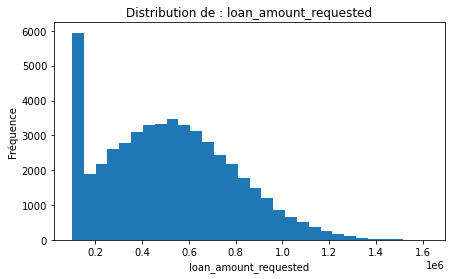

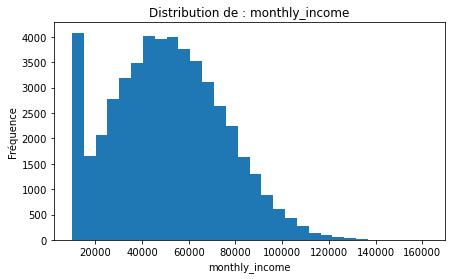

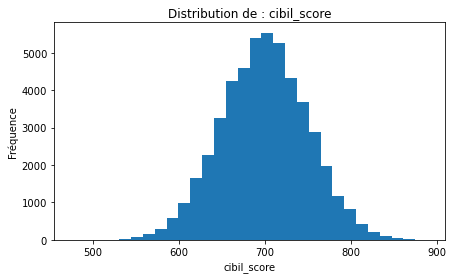

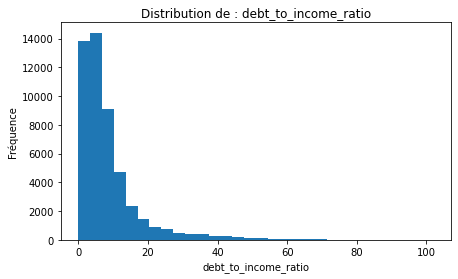

In [7]:
num_vars = ["loan_amount_requested", "monthly_income", "cibil_score", "debt_to_income_ratio"]

for col in num_vars:
    plt.figure(figsize=(7,4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution de : {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()


5. Détection des outliers (IQR)

In [8]:
def detect_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return outliers.shape[0]

print("\nDétection des valeurs extrêmes (méthode IQR) :")
for col in num_vars:
    print(f"{col} : {detect_outliers(col)} valeurs extrêmes détectées.")


Détection des valeurs extrêmes (méthode IQR) :
loan_amount_requested : 156 valeurs extrêmes détectées.
monthly_income : 194 valeurs extrêmes détectées.
cibil_score : 312 valeurs extrêmes détectées.
debt_to_income_ratio : 3973 valeurs extrêmes détectées.


In [9]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

num_vars = df.select_dtypes(include=['int64','float64']).columns

df_clean = df.copy()
for col in num_vars:
    df_clean = remove_outliers(df_clean, col)

print("Taille initiale :", df.shape[0])
print("Taille après suppression des outliers :", df_clean.shape[0])

df=df_clean

Taille initiale : 50000
Taille après suppression des outliers : 45082


6. Analyse bivariée : Revenu vs Montant demandé

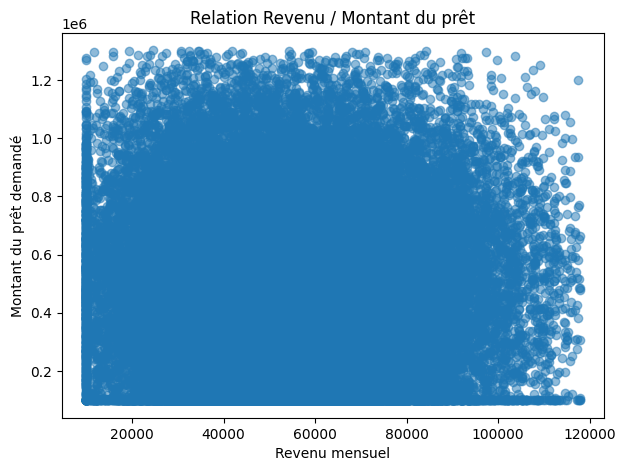

In [10]:
plt.figure(figsize=(7,5))
plt.scatter(df["monthly_income"], df["loan_amount_requested"], alpha=0.5)
plt.xlabel("Revenu mensuel")
plt.ylabel("Montant du prêt demandé")
plt.title("Relation Revenu / Montant du prêt")
plt.show()


7. Nettoyage des variables inutiles ou redondantes

In [11]:
df["dti_calc"] = df["existing_emis_monthly"] / df["monthly_income"]

display(df[["debt_to_income_ratio", "dti_calc"]].head()) #mes soupçons sont confirmés (juste que y'a un qui est en %).

# Variables numériques redondantes
df.drop(columns=['monthly_income', 'existing_emis_monthly',"dti_calc","purpose_of_loan","loan_status"], inplace=True) #on a le ratio qui est contenu dans debt_to_income_ratio

# Variables qualitatives inutiles ou trop corrélées
df.drop(columns=['customer_id', 'application_id', 'application_date',
                 'residential_address', 'fraud_type'], inplace=True) #fraud_type hyper corrélée avec fraud_flag
                                                                     #augmente la complexité computationnelle


,debt_to_income_ratio,dti_calc
0,3.17,0.031700
1,0.00,0.000000
3,13.89,0.138889
4,2.51,0.025057
5,4.54,0.045392


8. Séparation des variables

In [12]:
quanti = df.select_dtypes(include=['int64', 'float64'])
quali = df.select_dtypes(include=['object', 'bool'])

print("Variables quantitatives :", quanti.columns.tolist())
print("Variables qualitatives :", quali.columns.tolist())


Variables quantitatives : ['loan_amount_requested', 'loan_tenure_months', 'interest_rate_offered', 'cibil_score', 'debt_to_income_ratio', 'applicant_age', 'number_of_dependents']
Variables qualitatives : ['loan_type', 'employment_status', 'property_ownership_status', 'gender', 'fraud_flag']


9. Matrice de corrélation des variables quantitatives

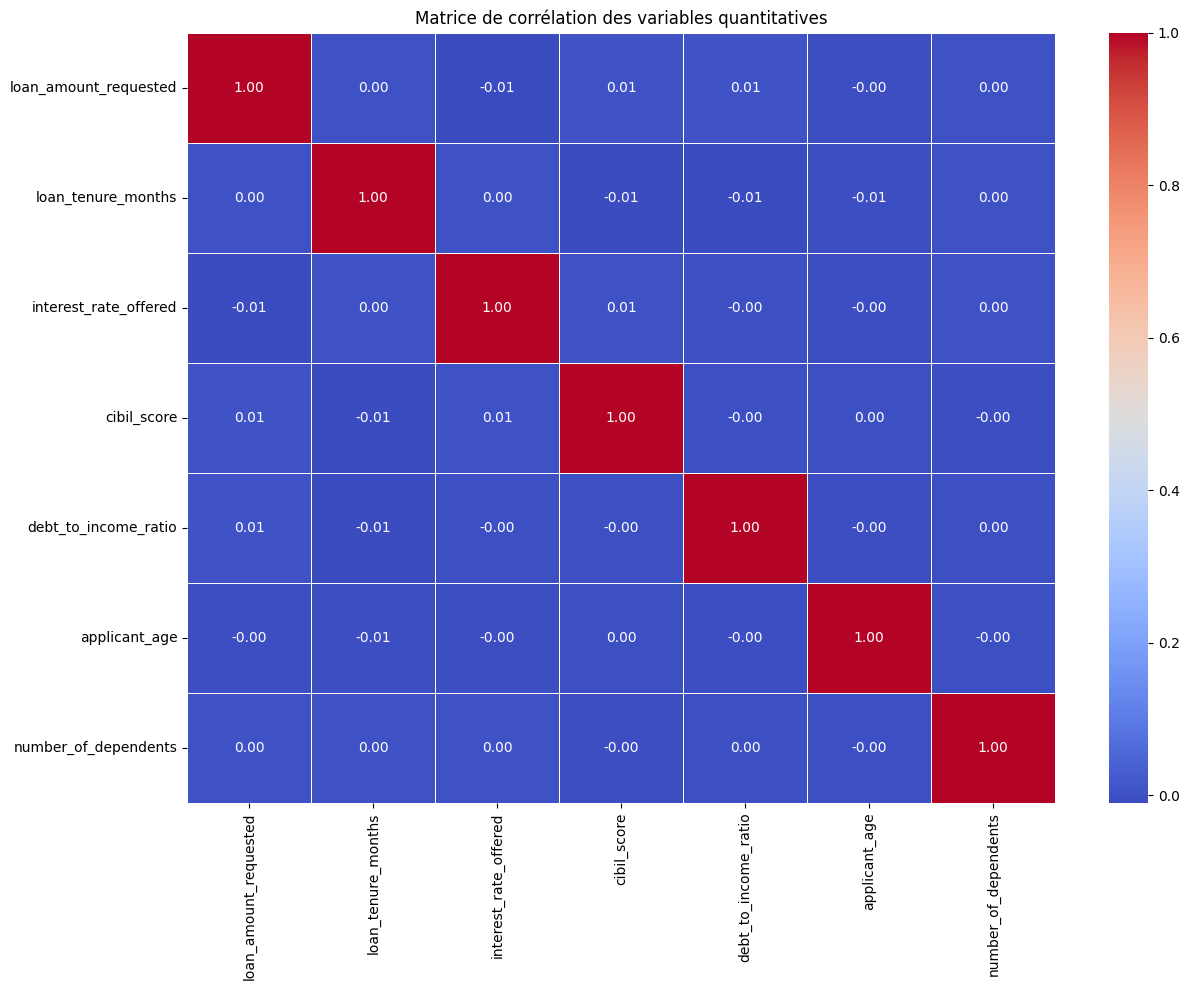

In [13]:
corr_quanti = quanti.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_quanti, annot=True, fmt=".2f", linewidths=.5, cmap="coolwarm")
plt.title("Matrice de corrélation des variables quantitatives")
plt.show()


10. Matrice de Cramér’s V pour les variables qualitatives

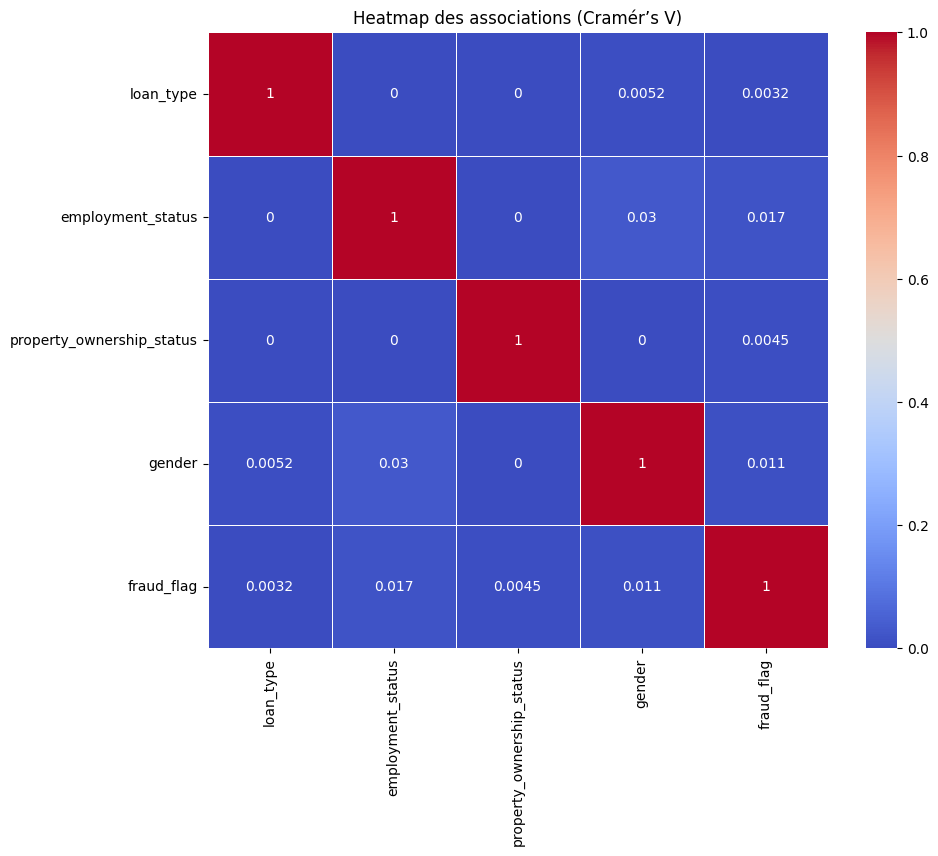

In [14]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

variables = df.select_dtypes(include=['object','bool']).columns
matrix = pd.DataFrame(index=variables, columns=variables, dtype=float)

for var1 in variables:
    for var2 in variables:
        matrix.loc[var1, var2] = cramers_v(df[var1], df[var2])

np.fill_diagonal(matrix.values, 1.0)

plt.figure(figsize=(10,8))
sns.heatmap(matrix.astype(float), annot=True, cmap="coolwarm", vmin=0, vmax=1, linewidths=0.5)
plt.title("Heatmap des associations (Cramér’s V)")
plt.show()


11. Visualisation des outliers par boxplot

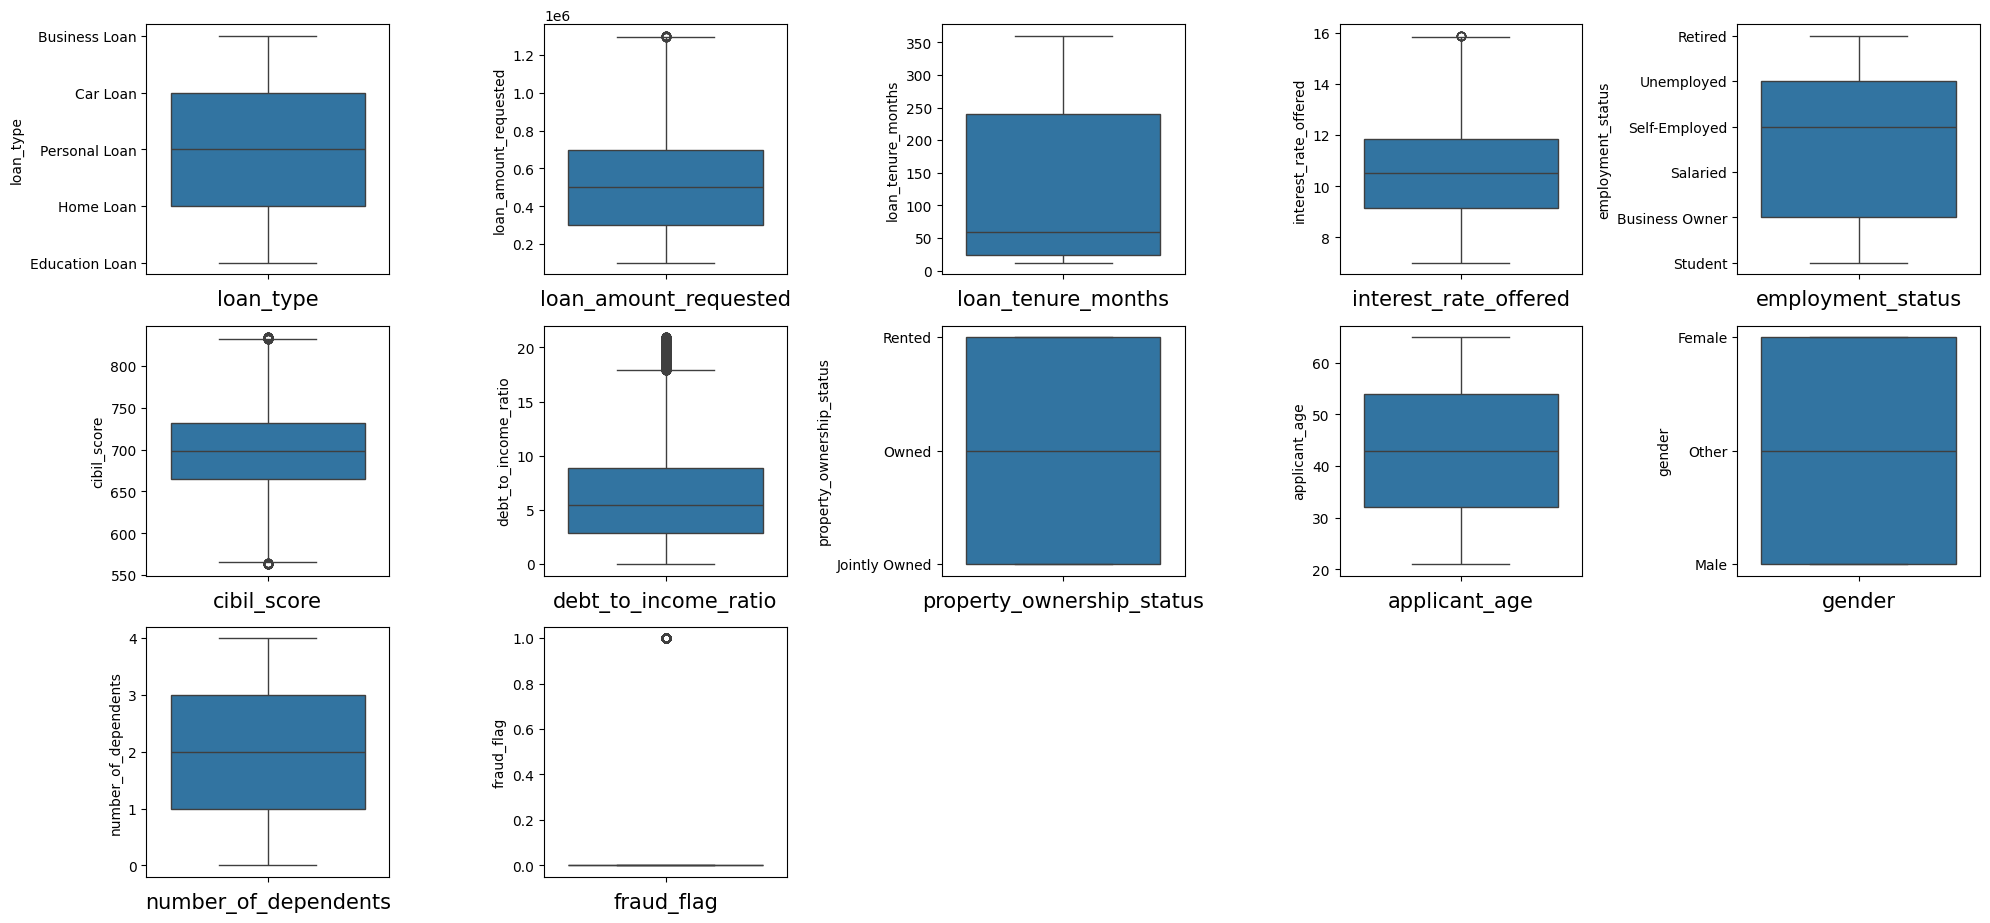

In [15]:
plt.figure(figsize=(20, 15))
plotnumber = 1

for col in df.columns:
    if plotnumber <= 24:
        ax = plt.subplot(5, 5, plotnumber)
        sns.boxplot(df[col])
        plt.xlabel(col, fontsize=15)
    plotnumber += 1

plt.tight_layout()
plt.show()


12. Encodage One-Hot des variables qualitatives

In [16]:
df_onehot = pd.get_dummies(df.select_dtypes(include=['object','bool']), drop_first=True).astype(int)


13. Matrice de corrélation des variables encodées

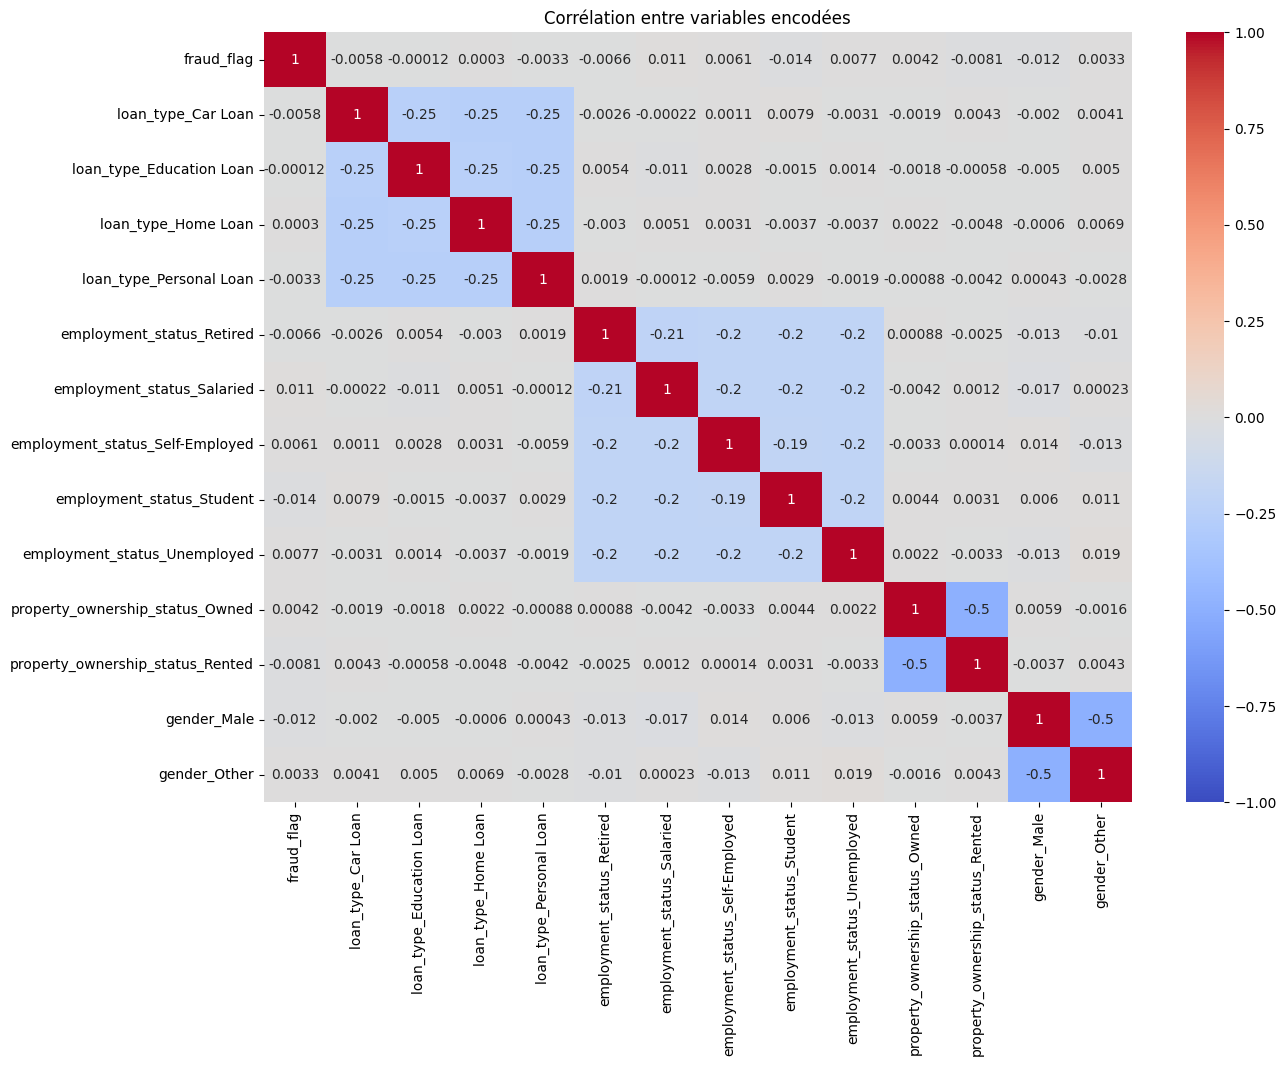

In [17]:
corr = df_onehot.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Corrélation entre variables encodées")
plt.show()


14. Matrice de corrélation des variables encodées QUANTI-QUALI

In [18]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fonction pour calculer Eta²
def eta_squared(df, quanti, quali):
    try:
        model = ols(f"{quanti} ~ C({quali})", data=df).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        eta_sq = anova_table['sum_sq']['C({})'.format(quali)] / anova_table['sum_sq'].sum()
        return eta_sq
    except:
        return np.nan  # si problème (ex. variable vide ou trop de modalités)

# Séparation des variables
quanti_cols = df.select_dtypes(include=['int64','float64']).columns
quali_cols = df.select_dtypes(include=['object','bool']).columns


In [19]:
# Initialisation de la matrice
eta_matrix = pd.DataFrame(index=quali_cols, columns=quanti_cols, dtype=float)

# Boucle sur toutes les paires quali-quanti
for ql in quali_cols:
    for qt in quanti_cols:
        eta_matrix.loc[ql, qt] = eta_squared(df, qt, ql)

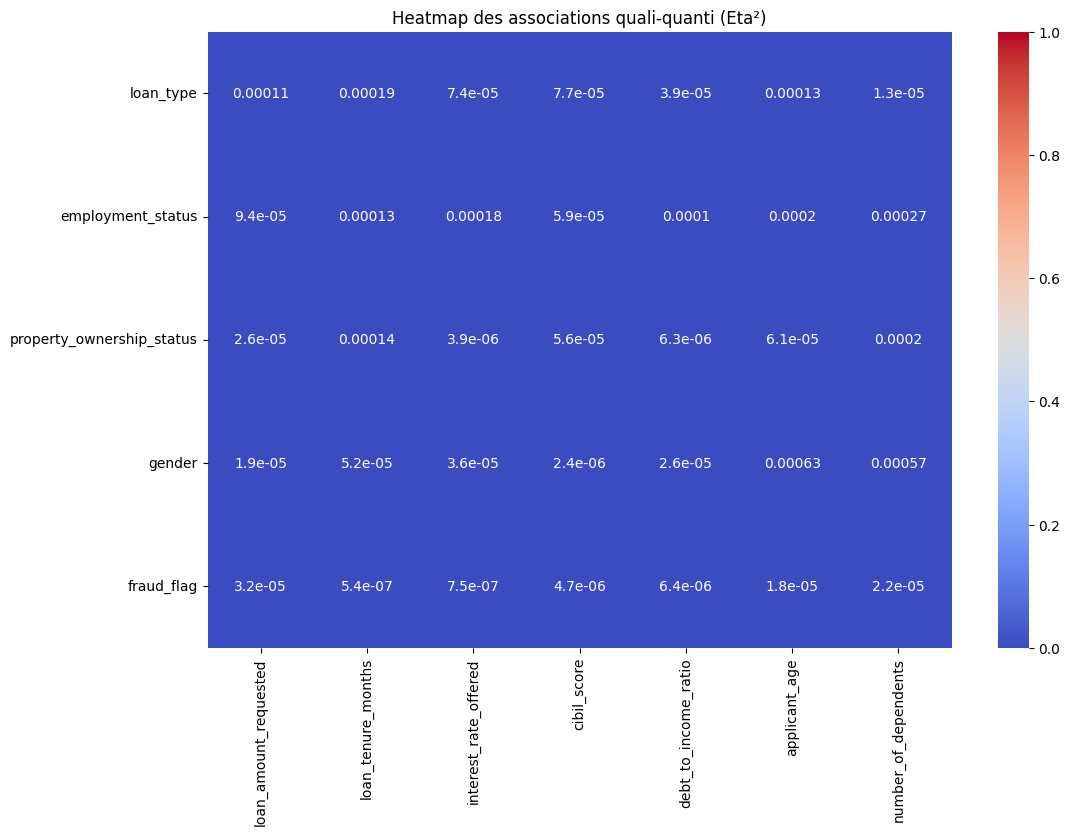

In [20]:
plt.figure(figsize=(12,8))
sns.heatmap(eta_matrix.astype(float), annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Heatmap des associations quali-quanti (Eta²)")
plt.show()

15. Réduction des variables trop corrélées

In [21]:
S = 0.5  # seuil de corrélation
corr_matrix = corr.abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > S)]

df_reduced = df_onehot.drop(columns=to_drop)
display(df_reduced.head())


,fraud_flag,loan_type_Car Loan,loan_type_Education Loan,loan_type_Home Loan,loan_type_Personal Loan,employment_status_Retired,employment_status_Salaried,employment_status_Self-Employed,employment_status_Student,employment_status_Unemployed,property_ownership_status_Owned,property_ownership_status_Rented,gender_Male,gender_Other
0,0,0,0,0,0,1,0,0,0,0,0,1,0,0
1,0,1,0,0,0,0,0,0,0,1,1,0,0,1
3,0,1,0,0,0,0,0,1,0,0,0,1,0,1
4,0,0,0,0,1,0,1,0,0,0,0,1,0,1
5,0,0,0,0,0,0,0,1,0,0,0,0,1,0


16. concaténation des deux datasets

In [22]:
final_df = pd.concat([quanti, df_reduced], axis=1)
#final_df.drop(columns=['cibil_score'], inplace=True)#j'avais oublié de retirer le score de cibil
final_df.head()

,loan_amount_requested,loan_tenure_months,interest_rate_offered,cibil_score,debt_to_income_ratio,applicant_age,number_of_dependents,fraud_flag,loan_type_Car Loan,loan_type_Education Loan,...,loan_type_Personal Loan,employment_status_Retired,employment_status_Salaried,employment_status_Self-Employed,employment_status_Student,employment_status_Unemployed,property_ownership_status_Owned,property_ownership_status_Rented,gender_Male,gender_Other
0,604000.0,12,11.66,714,3.17,28,3,0,0,0,...,0,1,0,0,0,0,0,1,0,0
1,100000.0,240,13.62,667,0.00,44,3,0,1,0,...,0,0,0,0,0,1,1,0,0,1
3,324000.0,120,10.36,647,13.89,27,4,0,1,0,...,0,0,0,1,0,0,0,1,0,1
4,100000.0,36,14.14,624,2.51,50,0,0,0,0,...,1,0,1,0,0,0,0,1,0,1
5,1164000.0,24,9.83,710,4.54,25,4,0,0,0,...,0,0,0,1,0,0,0,0,1,0


17. partie iForest

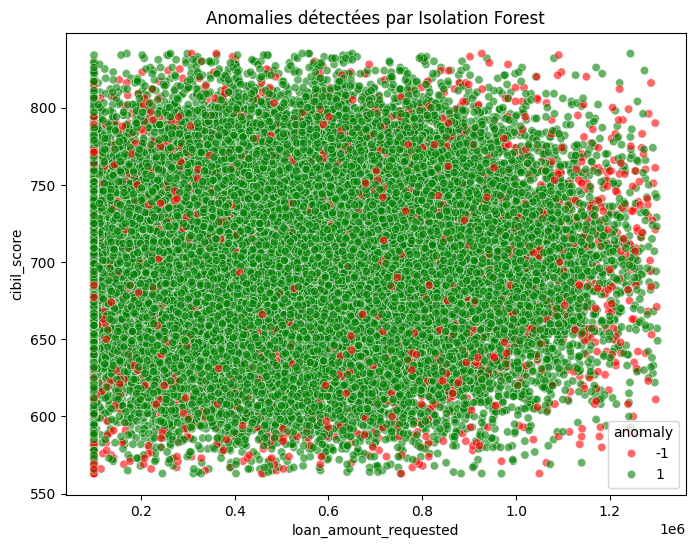

In [23]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# 1. Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(final_df)

# 2. Isolation Forest
iso = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso.fit(X_scaled)

# 3. Scores et prédictions
df['anomaly_score'] = iso.decision_function(X_scaled)
df['anomaly'] = iso.predict(X_scaled)  # -1 = anomalie, 1 = normal

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="loan_amount_requested", y="cibil_score", hue="anomaly", palette={1:'green', -1:'red'}, alpha=0.6)
plt.title("Anomalies détectées par Isolation Forest")
plt.show()


In [24]:
pd.crosstab(df['cibil_score'], df['anomaly'])#on a un bon ratio de détection 674 approuvés parmis les anomalies contre 1535 refus

anomaly,-1,1
cibil_score,,
563,6,9
564,0,6
565,2,5
566,4,7
567,3,10
...,...,...
831,2,9
832,0,10
833,2,6


18. Visualisation en 3 dimensions

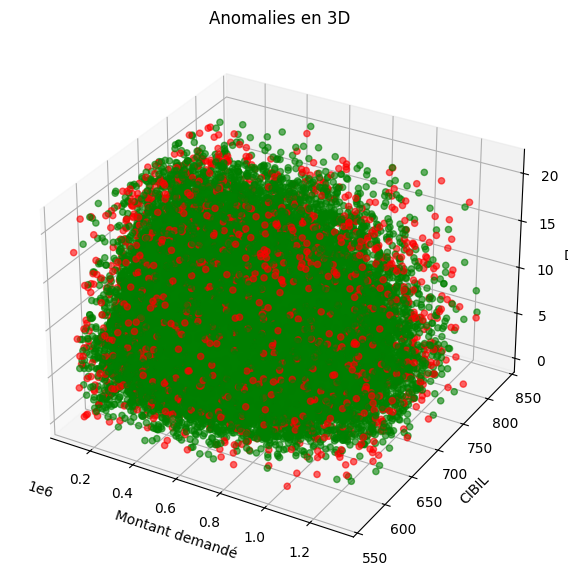

In [25]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
colors = df['anomaly'].map({1:'green', -1:'red'})

ax.scatter(df['loan_amount_requested'], df['cibil_score'], df['debt_to_income_ratio'], c=colors, alpha=0.6)
ax.set_xlabel('Montant demandé')
ax.set_ylabel('CIBIL')
ax.set_zlabel('DTI')
plt.title("Anomalies en 3D")
plt.show()


19. analyse en composante principale

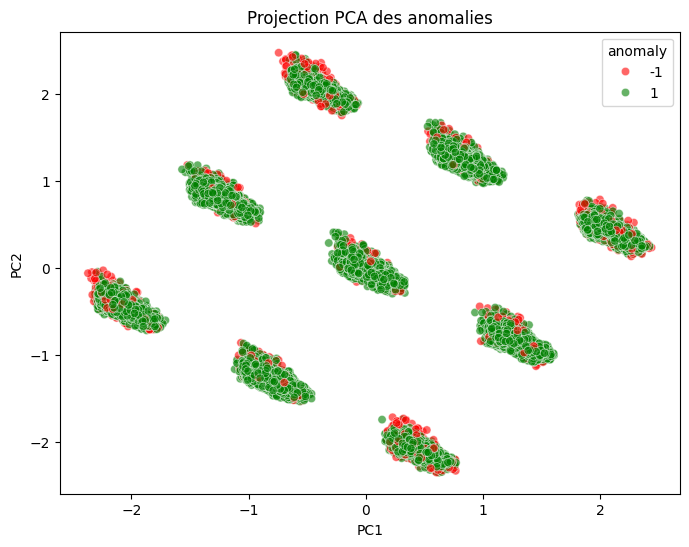

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['anomaly'], palette={1:'green', -1:'red'}, alpha=0.6)
plt.title("Projection PCA des anomalies")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

#DETECTION D'ANOMALIE AVEC IFOREST

###Etape d'entraînement


In [27]:
df_fraud_flag = final_df.copy()

In [28]:
from sklearn.model_selection import train_test_split

df = df_fraud_flag  # ton DataFrame complet avec la cible

X = df.drop(columns=['fraud_flag'])
y = df['fraud_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y
)

# Au passage pour moi c'est pas pertinent de scale les données

In [29]:
iforest_model = IsolationForest(
    n_estimators=100,        # t = 100 arbres (valeur par défaut du PDF)
    max_samples='auto',      # ψ = 256 (valeur par défaut 'auto' dans sklearn)
    contamination=0.1,    # Proportion attendue d'anomalies. Quand on fixe en 'auto' le modèle identifie +70% des données comme des outliers ce qui est mauvais
    random_state=42,         # Pour la reproductibilité
    verbose=1                # Affiche une barre de progression
)

In [30]:
# Entraînement du modèle sur les données X_train
iforest_model.fit(X_train)

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.2s finished


IsolationForest(contamination=0.1, random_state=42, verbose=1)

In [31]:
X_train

,loan_amount_requested,loan_tenure_months,interest_rate_offered,cibil_score,debt_to_income_ratio,applicant_age,number_of_dependents,loan_type_Car Loan,loan_type_Education Loan,loan_type_Home Loan,loan_type_Personal Loan,employment_status_Retired,employment_status_Salaried,employment_status_Self-Employed,employment_status_Student,employment_status_Unemployed,property_ownership_status_Owned,property_ownership_status_Rented,gender_Male,gender_Other
37778,446000.0,240,10.56,671,4.38,45,1,0,1,0,0,0,0,0,1,0,0,1,0,0
27723,679000.0,36,11.46,685,4.77,58,2,0,0,1,0,0,0,0,0,1,0,1,0,1
9851,715000.0,12,10.70,723,16.12,22,4,0,0,1,0,0,0,0,1,0,0,1,0,0
47535,798000.0,120,12.53,715,0.00,23,1,0,0,1,0,1,0,0,0,0,0,0,0,1
11825,377000.0,24,11.56,618,11.94,47,2,0,0,0,1,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44412,106000.0,12,11.66,609,7.10,30,1,0,1,0,0,0,1,0,0,0,0,1,0,0
4475,133000.0,240,10.35,669,0.00,51,4,0,0,0,0,0,0,0,1,0,1,0,0,0
29110,394000.0,24,11.80,758,3.27,56,3,0,0,0,0,0,0,0,0,1,1,0,1,0
27364,100000.0,360,11.68,696,10.91,24,1,0,0,0,1,0,0,0,0,1,1,0,0,1


In [32]:
# Prédiction des étiquettes (-1 = anomalie, 1 = normal)
y_pred = iforest_model.predict(X_train)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.2s finished


In [33]:
anomaly_scores = -iforest_model.score_samples(X_train)
X_train['iforest_anomaly_score'] = anomaly_scores

# -1 (iForest Anomalie) devient 1 (notre label "Fraude")
#  1 (iForest Normal)  devient 0 (notre label "Normal")
X_train['iforest_anomaly_label'] = np.where(y_pred == -1, 1, 0)


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.3s finished


In [34]:
print("Proportion d'anomalies en accord avec le paramètre contamination :",(len(X_train[X_train['iforest_anomaly_label'] == 1])/len(X_train))*100,"%")


Proportion d'anomalies en accord avec le paramètre contamination : 10.0013863856925 %


###Score d'anomalie et métriques


In [35]:
# CALCUL DU RMSE ET MÉTRIQUES DE PERFORMANCE

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_train, X_train['iforest_anomaly_label']))
print("rmse :", rmse)
# 2. MSE (Mean Squared Error)
mse = mean_squared_error(y_train, X_train['iforest_anomaly_label'])
print("mse :", mse)
# 3. MAE (Mean Absolute Error)
mae = mean_absolute_error(y_train, X_train['iforest_anomaly_label'])
print("mae :", mae)
# 4. Nombre de lignes où l'une est différente de l'autre
nb_differences = (y_train != X_train['iforest_anomaly_label']).sum()
print(f"Nombre de lignes différentes : {nb_differences}","soit", round(nb_differences/len(X_train)*100,2),"% des données d'entraînement")

rmse : 0.34093192349671647
mse : 0.11623457645917094
mae : 0.11623457645917094
Nombre de lignes différentes : 4192 soit 11.62 % des données d'entraînement


In [36]:
nb_fn_train = ((y_train == 1) & (X_train['iforest_anomaly_label'] == 0)).sum()
print("Nombre de fraudes manquées (FN) :", nb_fn_train)
pct_fn_train = (nb_fn_train / (y_train==1).sum()) * 100
print(f"Fraudes manquées : {nb_fn_train} soit {pct_fn_train:.2f} % des données de fraudes")

Nombre de fraudes manquées (FN) : 656
Fraudes manquées : 656 soit 90.23 % des données de fraudes


  Comparaison entre Anomaly Score de l'article et Anomaly Score fourni par Python

1. Implémentation de l'anomaly score de l'article

In [37]:
import numpy as np
from sklearn.ensemble import IsolationForest

# 1) Fonction c(n) du papier (normalisation de la longueur de chemin)
def c_of_n(n):
    if n <= 1:
        return 0.0
    return 2.0 * (np.log(n - 1.0) + 0.5772156649) - 2.0 * (n - 1.0) / n

# 2) Apprentissage de l'Isolation Forest "brute" (sans utiliser score_samples)
iforest = IsolationForest(
    n_estimators=100,
    max_samples='auto',
    contamination='auto',
    random_state=42,
    n_jobs=-1
)
iforest.fit(X_train.values)          # ou X_train numpy

# 3) Calcul de la longueur moyenne de chemin E(h(x)) pour chaque instance

def path_length_single_tree(tree, x):
    """
    Longueur de chemin d'un point x dans UN iTree (suivant la définition du papier).
    x : array 1D (features d'un point)
    tree : sklearn.tree._tree.Tree (iforest.estimators_[i].tree_)
    """
    node = 0
    length = 0.0

    while True:
        # Si feuille : on renvoie longueur + c(size)
        if tree.children_left[node] == tree.children_right[node]:
            n_node_samples = tree.n_node_samples[node]
            length += c_of_n(n_node_samples)
            break

        feature = tree.feature[node]
        threshold = tree.threshold[node]

        if x[feature] <= threshold:
            node = tree.children_left[node]
        else:
            node = tree.children_right[node]

        length += 1.0

    return length

def average_path_length(iforest, X):
    """
    E(h(x)) pour chaque x de X, en moyennant sur tous les arbres de l'IF.
    X : array 2D (n_samples, n_features)
    """
    X = np.asarray(X)
    n_samples = X.shape[0]
    n_trees = len(iforest.estimators_)
    paths = np.zeros(n_samples, dtype=float)

    # Taille de l'échantillon utilisé pour construire chaque arbre (n dans c(n))
    # max_samples_ est un entier dans l'objet sklearn une fois l'IF entraîné
    n_subsample = iforest.max_samples_

    for tree in iforest.estimators_:
        tree_struct = tree.tree_
        # longueur pour chaque point dans ce tree
        pl_tree = np.array([path_length_single_tree(tree_struct, x) for x in X])
        paths += pl_tree

    paths /= n_trees  # moyenne sur les arbres
    return paths, n_subsample

# 4) Score d’anomalie s(x) du papier
H, n_subsample = average_path_length(iforest, X_train.values)   # E(h(x))
c_n = c_of_n(n_subsample)

# s(x) = 2^(-E(h(x))/c(n)), plus proche de 1 = plus anormal
anomaly_score_iforest = np.power(2.0, -H / c_n)

# 5) Affichage des résultats
anomaly_score_iforest


array([0.48874545, 0.50108487, 0.56441812, ..., 0.47278779, 0.58407881,
       0.49644037])

In [38]:
pd.DataFrame(anomaly_score_iforest)

,0
0,0.488745
1,0.501085
2,0.564418
3,0.530139
4,0.495564
...,...
36060,0.508267
36061,0.509189
36062,0.472788
36063,0.584079


In [39]:
pd.DataFrame(anomaly_score_iforest).describe()

,0
count,36065.000000
mean,0.508737
std,0.030515
min,0.437986
25%,0.488134
50%,0.503522
75%,0.520543
max,0.629581


In [40]:
X_train["iforest_anomaly_score"]

,iforest_anomaly_score
37778,0.515776
27723,0.516332
9851,0.563329
47535,0.530745
11825,0.511076
...,...
44412,0.526491
4475,0.503738
29110,0.497032
27364,0.569934


2. Comparaison des deux scores d'anomalie

In [41]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1) Evenement : on repart des mêmes features que pour l'entraînement
#    -> ton iForest a été fit sur X_train (sans la colonne 'fraud_flag')
X_train_array = X_train.drop(
    columns=[col for col in ["fraud_flag"] if col in X_train.columns]
).drop(
    columns=[col for col in ["iforest_anomaly_score",
                             "iforest_anomaly_label"]
             if col in X_train.columns],
    errors="ignore"
).values

# 2) Score "classique" scikit-learn (normalité -> on inverse le signe)
score_normalite_sklearn = iforest_model.score_samples(X_train_array)
anomaly_scores_sklearn = -score_normalite_sklearn


# 3) Mettre les deux scores sur la même échelle (min-max) pour comparer
scaler_mm = MinMaxScaler()
scores_scaled = scaler_mm.fit_transform(
    np.vstack([anomaly_score_iforest, anomaly_scores_sklearn]).T
)

score_paper_scaled = scores_scaled[:, 0]
score_skl_scaled   = scores_scaled[:, 1]

# 4) Différences et corrélation
abs_diff = np.abs(score_paper_scaled - score_skl_scaled)
print("Différence absolue moyenne :", abs_diff.mean())
print("Différence absolue max      :", abs_diff.max())
print("Corrélation de Pearson      :",
      np.corrcoef(score_paper_scaled, score_skl_scaled)[0, 1])

# 5) Vérifier si les rangs sont identiques (ordre des anomalies)
rank_paper = np.argsort(np.argsort(-score_paper_scaled))
rank_skl   = np.argsort(np.argsort(-score_skl_scaled))

nb_diff_ranks = (rank_paper != rank_skl).sum()
print("Nombre de rangs différents :", nb_diff_ranks, "sur", len(rank_paper))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s


Différence absolue moyenne : 0.15339926607052154
Différence absolue max      : 0.3949320596376782
Corrélation de Pearson      : 0.843458870362932
Nombre de rangs différents : 36057 sur 36065


[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.3s finished


In [42]:
# ÉVALUATION COMPLÈTE POUR LA DÉTECTION D'ANOMALIES

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    ConfusionMatrixDisplay, f1_score
)


🔍 MATRICE DE CONFUSION :
   (Réel en ligne, Prédit en colonne)

               Prédit=0      Prédit=1
  Réel=0 (N)   TN= 31802       FP=  3536
  Réel=1 (F)   FN=   656       TP=    71


Text(0.5, 1.0, 'Matrice de Confusion')

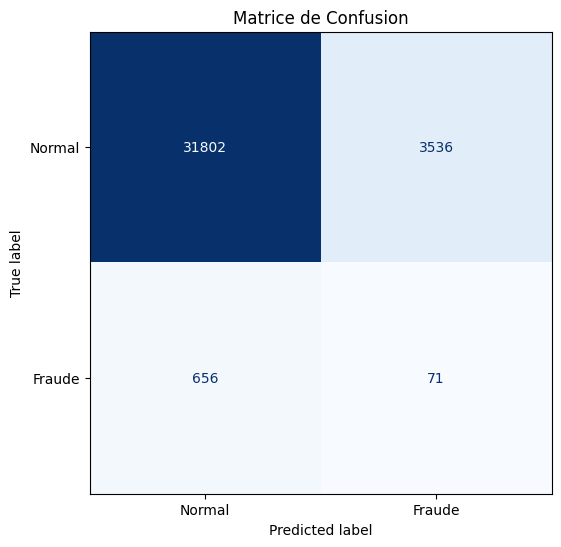

In [43]:
#Matrice de confusion

cm = confusion_matrix(y_train,
                      X_train['iforest_anomaly_label'])

print("\n🔍 MATRICE DE CONFUSION :")
print("   (Réel en ligne, Prédit en colonne)\n")
print(f"               Prédit=0      Prédit=1")
print(f"  Réel=0 (N)   TN={cm[0,0]:>6}       FP={cm[0,1]:>6}")
print(f"  Réel=1 (F)   FN={cm[1,0]:>6}       TP={cm[1,1]:>6}")

# Visualisation de la matrice
fig, ax = plt.subplots(figsize=(8, 6))  # Un seul axe

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Normal', 'Fraude'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matrice de Confusion')

In [44]:
tn, fp, fn, tp = cm.ravel()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = f1_score(y_train, X_train['iforest_anomaly_label'])
accuracy = (tp + tn) / (tp + tn + fp + fn)

print(f"\n📊 MÉTRIQUES DE CLASSIFICATION :")
print(f"  Accuracy    : {accuracy:.4f}  ({accuracy:.2%})")
print(f"  Précision   : {precision:.4f}  (Quand iForest prédit 'fraude', à quel point a-t-il raison ?)")
print(f"  Rappel      : {recall:.4f}  (Quelle proportion des vraies fraudes iForest détecte-t-il ?)")
print(f"  F1-Score    : {f1:.4f}  (Moyenne harmonique de Précision et Rappel)")

'''De ce que je vois ç a prédit bien les normaux mais pas très bien les fraudes, l'Accuracy est haute parce que les normaux sont très bien preédits mais
quand on se penche sur les fraudes avec precision on voit que c'est médiocre, ce sont les conséquences du fait que le dataset est déséquilibré(trop de "normal")'''


📊 MÉTRIQUES DE CLASSIFICATION :
  Accuracy    : 0.8838  (88.38%)
  Précision   : 0.0197  (Quand iForest prédit 'fraude', à quel point a-t-il raison ?)
  Rappel      : 0.0977  (Quelle proportion des vraies fraudes iForest détecte-t-il ?)
  F1-Score    : 0.0328  (Moyenne harmonique de Précision et Rappel)


'De ce que je vois ç a prédit bien les normaux mais pas très bien les fraudes, l\'Accuracy est haute parce que les normaux sont très bien preédits mais\nquand on se penche sur les fraudes avec precision on voit que c\'est médiocre, ce sont les conséquences du fait que le dataset est déséquilibré(trop de "normal")'

ROC-AUC Score : 0.5010
   Interprétation :
   • 0.5 = aléatoire (mauvais)
   • 0.7-0.8 = acceptable
   • 0.8-0.9 = bon
   • >0.9 = excellent


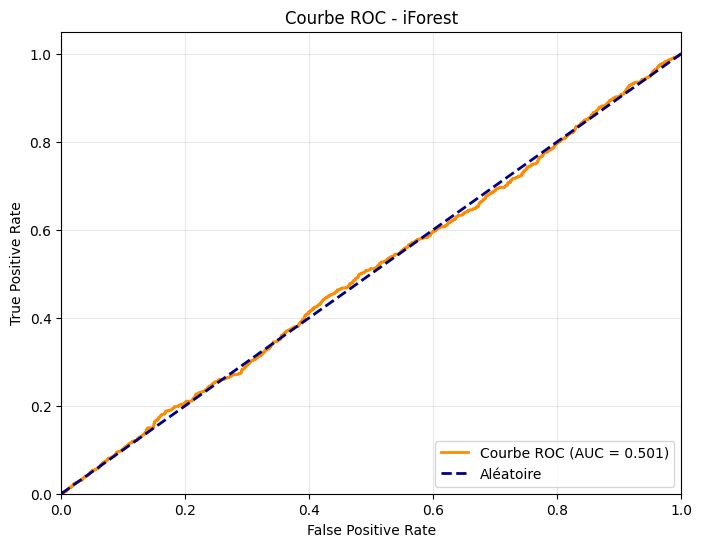

In [45]:
# ROC-AUC (nécessite les scores, pas juste les labels)

if 'iforest_anomaly_score' in X_train.columns:
    scores_for_auc = -X_train['iforest_anomaly_score']
    roc_auc = roc_auc_score(y_train, scores_for_auc)

    print(f"ROC-AUC Score : {roc_auc:.4f}")
    print(f"   Interprétation :")
    print(f"   • 0.5 = aléatoire (mauvais)")
    print(f"   • 0.7-0.8 = acceptable")
    print(f"   • 0.8-0.9 = bon")
    print(f"   • >0.9 = excellent")

    # Courbe ROC - NOUVELLE FIGURE
    plt.figure(figsize=(8, 6))

    fpr, tpr, _ = roc_curve(y_train, scores_for_auc)
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Courbe ROC (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aléatoire')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Courbe ROC - iForest')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

else:
    print("ROC-AUC non calculé : colonne 'iforest_anomaly_score' manquante")


📊 PR-AUC Score : 0.0203
   Interprétation (particulièrement important pour données déséquilibrées) :
   • Valeur aléatoire = proportion de fraudes = 0.020
   • >0.5 = mieux qu'aléatoire


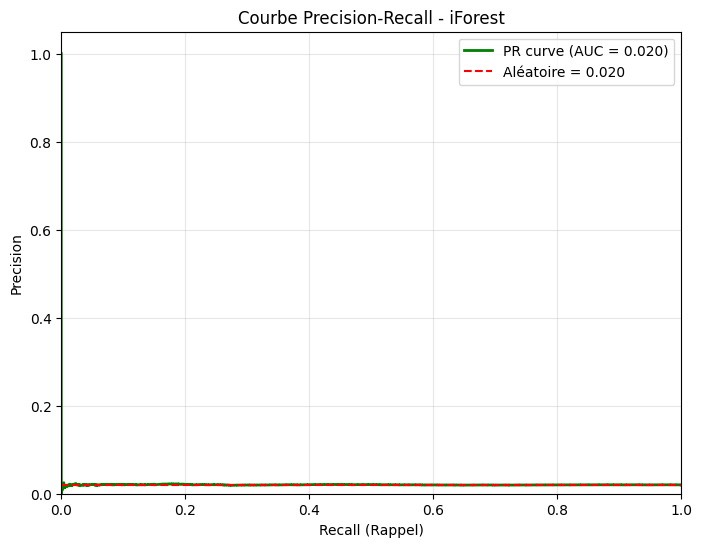

In [46]:
# PR-AUC (Precision-Recall AUC)

if 'iforest_anomaly_score' in X_train.columns:
    pr_auc = average_precision_score(y_train, scores_for_auc)

    print(f"\n📊 PR-AUC Score : {pr_auc:.4f}")
    print(f"   Interprétation (particulièrement important pour données déséquilibrées) :")
    print(f"   • Valeur aléatoire = proportion de fraudes = {y_train.mean():.3f}")
    print(f"   • >0.5 = mieux qu'aléatoire")

    # Courbe Precision-Recall - NOUVELLE FIGURE
    plt.figure(figsize=(8, 6))

    precision_vals, recall_vals, _ = precision_recall_curve(
        y_train, scores_for_auc
    )

    # Valeur aléatoire (baseline)
    random_baseline = y_train.mean()

    plt.plot(recall_vals, precision_vals, color='green', lw=2,
             label=f'PR curve (AUC = {pr_auc:.3f})')
    plt.axhline(y=random_baseline, color='r', linestyle='--',
                label=f'Aléatoire = {random_baseline:.3f}')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall (Rappel)')
    plt.ylabel('Precision')
    plt.title('Courbe Precision-Recall - iForest')
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.show()

**Conclusion :** Les métriques sont pas intéréssantes car le dataset est apparemment déséquilibrés, je dois chercher d'autres métriques (j'ai vu des métriques dans des études et le cours comme l'AUPRC, je vais rajouter ça après Barcelone)

###Métriques adaptées au déséquilibre du dataset

In [47]:
import numpy as np
from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    f1_score, balanced_accuracy_score
)

y_true = y_train.values                         # vérité de terrain
y_score = scores_for_auc                        # ton score d'anomalie iForest
y_pred  = X_train['iforest_anomaly_label'].values  # tes prédictions binaires 0/1

1. AUPRC / Average Precision



AUPRC / Average Precision : 0.0203


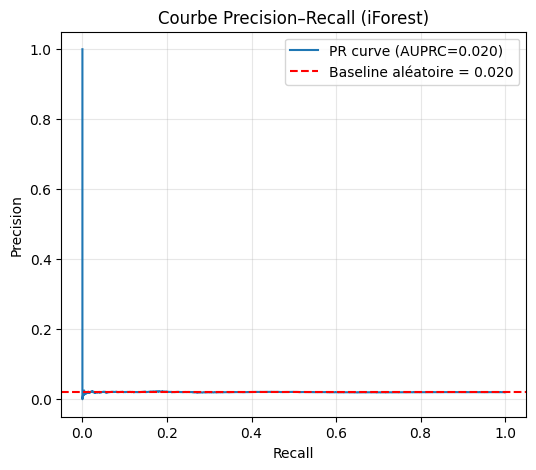

In [48]:
# AUPRC (Average Precision = approximation de l'AUPRC)
auprc = average_precision_score(y_true, y_score)
print(f"AUPRC / Average Precision : {auprc:.4f}")

# Courbe Precision–Recall
prec, rec, thr = precision_recall_curve(y_true, y_score)

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 5))
plt.plot(rec, prec, label=f"PR curve (AUPRC={auprc:.3f})")
plt.axhline(y=y_true.mean(), color='r', ls='--',
            label=f"Baseline aléatoire = {y_true.mean():.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision–Recall (iForest)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


2. Fβ‑score (favoriser le rappel)

In [49]:
# F1 standard
f1 = f1_score(y_true, y_pred)
print(f"F1-score (beta=1) : {f1:.4f}")

# Exemple F2 (donne plus de poids au rappel)
from sklearn.metrics import fbeta_score
f2 = fbeta_score(y_true, y_pred, beta=2)
print(f"F2-score (beta=2, rappel prioritaire) : {f2:.4f}")


F1-score (beta=1) : 0.0328
F2-score (beta=2, rappel prioritaire) : 0.0545


3. Precision@k / Recall@k


In [50]:
def precision_recall_at_k(y_true, y_score, k):
    idx = np.argsort(-y_score)          # tri décroissant des scores
    top_k = idx[:k]
    y_top = y_true[top_k]
    precision_k = y_top.mean()          # proportion de fraudes dans le top-k
    recall_k = y_top.sum() / y_true.sum()
    return precision_k, recall_k

# Exemple : k = 500 transactions les plus suspectes
k = 500
p_k, r_k = precision_recall_at_k(y_true, y_score, k)
print(f"Precision@{k} : {p_k:.4f}")
print(f"Recall@{k}    : {r_k:.4f}")

# Variante : top p% du dataset
p = 1.0  # 1 %
k_pct = int(len(y_true) * p / 100)
p_top, r_top = precision_recall_at_k(y_true, y_score, k_pct)
print(f"Precision top {p}% : {p_top:.4f}")
print(f"Recall top {p}%    : {r_top:.4f}")

Precision@500 : 0.0200
Recall@500    : 0.0138
Precision top 1.0% : 0.0194
Recall top 1.0%    : 0.0096


4. Balanced Accuracy et G‑mean

In [51]:
# Balanced accuracy
bal_acc = balanced_accuracy_score(y_true, y_pred)
print(f"Balanced accuracy : {bal_acc:.4f}")

# G-mean = sqrt(sensitivity * specificity)
from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0  # rappel de la classe 1
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0  # rappel de la classe 0
gmean = np.sqrt(sensitivity * specificity)
print(f"G-mean : {gmean:.4f}")


Balanced accuracy : 0.4988
G-mean : 0.2965


5. Matthews Correlation Coefficient (MCC)

In [52]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(y_true, y_pred)
print(f"Matthews Correlation Coefficient (MCC) : {mcc:.4f}")

Matthews Correlation Coefficient (MCC) : -0.0011


6. Kappa de Cohen

In [53]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(y_true, y_pred)

print("Kappa de Cohen (IsolationForest) :", round(kappa, 4))

Kappa de Cohen (IsolationForest) : -0.0008


7. Balanced Accuracy

In [54]:
bacc = balanced_accuracy_score(y_true, y_pred)
print(f"Balanced Accuracy (IsolationForest) :", round(bacc, 4))

Balanced Accuracy (IsolationForest) : 0.4988


8. Indice de Jaccard

In [55]:
from sklearn.metrics import jaccard_score

jaccard = jaccard_score(y_true, y_pred)
print(f"Indice de Jaccard (IsolationForest) :", round(jaccard, 4))

Indice de Jaccard (IsolationForest) : 0.0167


###Optimisation des hyperparamètres d'iForest


1.  GridSearchCV

In [56]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# Pipeline : scaler puis iForest
pipeline_gs = Pipeline([
    ('scaler', StandardScaler()),
    ('iforest', IsolationForest(random_state=42))
])

# Grille d’hyperparamètres (préfixe 'iforest__')
param_grid = {
    'iforest__n_estimators':  [50, 100, 200],
    'iforest__max_samples':   ['auto', 128, 256, 512],
    'iforest__contamination': [0.01, 0.02, 0.05, 0.1],
    'iforest__max_features':  [1.0, 0.8, 0.5]
}

# GridSearchCV : on optimise un score simple (roc_auc sur le label binaire)
grid_search = GridSearchCV(
    estimator=pipeline_gs,
    param_grid=param_grid,
    scoring='roc_auc',   # tu peux définir un scorer custom si tu veux AUPRC
    cv=5,
    n_jobs=-1,
    verbose=2
)

print("🚀 Démarrage du GridSearchCV...")
grid_search.fit(X_train, y_train)

print("\n✅ OPTIMISATION TERMINÉE (GridSearch)")
print("Meilleurs paramètres :")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\n📈 Meilleur score ROC-AUC : {grid_search.best_score_:.4f}")

# Meilleur pipeline iForest issu du GridSearch
best_pipeline_grid = grid_search.best_estimator_
best_iforest_grid  = best_pipeline_grid.named_steps['iforest']


🚀 Démarrage du GridSearchCV...
Fitting 5 folds for each of 144 candidates, totalling 720 fits

✅ OPTIMISATION TERMINÉE (GridSearch)
Meilleurs paramètres :
  iforest__contamination: 0.01
  iforest__max_features: 0.8
  iforest__max_samples: 512
  iforest__n_estimators: 50

📈 Meilleur score ROC-AUC : 0.5091


2. Optuna

In [57]:
!pip install optuna

import optuna
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    f1_score, fbeta_score,
    balanced_accuracy_score, confusion_matrix,
    jaccard_score, matthews_corrcoef,
    cohen_kappa_score
)

# ------------------------------------------------------------------
# 1. Préparation des données
# ------------------------------------------------------------------
# On part du split propre fait AVANT :
# X_train, X_test, y_train, y_test = train_test_split(...)

cols_to_drop = ['iforest_anomaly_score', 'iforest_anomaly_label']
cols_to_drop = [c for c in cols_to_drop if c in X_train.columns]

X_train_features = X_train.drop(columns=cols_to_drop).copy()
y_train_array   = y_train.values      # si besoin


print(f"📊 Dimensions : {X_train_features.shape} features, {len(y_train_array)} labels")

X_values = X_train_features.values        # pour aller plus vite dans la CV


# ------------------------------------------------------------------
# 2. Fonctions utilitaires pour les métriques
# ------------------------------------------------------------------
def precision_recall_at_k(y_true, y_score, k):
    idx = np.argsort(-y_score)
    top_k = idx[:k]
    y_top = y_true[top_k]
    precision_k = y_top.mean()                 # proportion de fraudes dans le top-k
    recall_k = y_top.sum() / y_true.sum() if y_true.sum() > 0 else 0.0
    return precision_k, recall_k


def compute_metrics(y_true, y_pred, y_score):
    """Calcule toutes les métriques sur un fold et renvoie un dict."""
    # AUPRC (Average Precision)
    auprc = average_precision_score(y_true, y_score)

    # F1 et F2
    f1 = f1_score(y_true, y_pred)
    f2 = fbeta_score(y_true, y_pred, beta=2)

    # Precision@k / Recall@k (on prend k = 1% du dataset du fold, min 1)
    k = max(1, int(len(y_true) * 0.01))
    p_k, r_k = precision_recall_at_k(y_true, y_score, k)

    # Balanced accuracy
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    # G-mean
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    gmean = np.sqrt(sensitivity * specificity)

    # Jaccard
    jacc = jaccard_score(y_true, y_pred)

    # MCC
    mcc = matthews_corrcoef(y_true, y_pred)

    # Kappa de Cohen
    kappa = cohen_kappa_score(y_true, y_pred)

    return {
        "auprc": auprc,
        "f1": f1,
        "f2": f2,
        "p_k": p_k,
        "r_k": r_k,
        "bal_acc": bal_acc,
        "gmean": gmean,
        "jaccard": jacc,
        "mcc": mcc,
        "kappa": kappa
    }


# ------------------------------------------------------------------
# 3. Fonction objective Optuna
# ------------------------------------------------------------------
def objective(trial):
    # Hyperparamètres du scaler
    with_mean = trial.suggest_categorical('scaler_with_mean', [True, False])
    with_std  = trial.suggest_categorical('scaler_with_std',  [True, False])

    # Hyperparamètres d'iForest
    n_estimators  = trial.suggest_int('iforest_n_estimators', 100, 400)
    max_samples   = trial.suggest_categorical('iforest_max_samples',
                                              [128, 256, 512, 'auto'])
    contamination = trial.suggest_float('iforest_contamination', 0.01, 0.2)
    max_features  = trial.suggest_float('iforest_max_features', 0.5, 1.0)
    bootstrap     = trial.suggest_categorical('iforest_bootstrap', [True, False])
    n_jobs        = -1

    # Pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler(with_mean=with_mean, with_std=with_std)),
        ('iforest', IsolationForest(
            n_estimators=n_estimators,
            max_samples=max_samples,
            contamination=contamination,
            max_features=max_features,
            bootstrap=bootstrap,
            random_state=42,
            n_jobs=n_jobs
        ))
    ])

    # Cross-validation stratifiée
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Stockage des métriques sur les folds
    metrics_list = []

    for train_idx, valid_idx in cv.split(X_values, y_train_array):
        X_tr, X_val = X_values[train_idx], X_values[valid_idx]
        y_tr, y_val = y_train_array[train_idx], y_train_array[valid_idx]

        pipeline.fit(X_tr)

        # Scores continus et labels prédits
        X_val_scaled = pipeline.named_steps['scaler'].transform(X_val)
        scores = pipeline.named_steps['iforest'].decision_function(X_val_scaled)
        y_score = -scores                       # plus grand = plus anormal

        y_pred_iforest = pipeline.named_steps['iforest'].predict(X_val_scaled)
        y_pred = np.where(y_pred_iforest == -1, 1, 0)

        metrics_list.append(compute_metrics(y_val, y_pred, y_score))

    # Moyenne des métriques sur les folds
    mean_metrics = {
        k: np.mean([m[k] for m in metrics_list]) for k in metrics_list[0].keys()
    }

    # Score composite pour Optuna (poids à ajuster si besoin)
    score = (
        3.0 * mean_metrics["auprc"] +
        2.0 * mean_metrics["f2"] +
        2.0 * mean_metrics["r_k"] +
        1.5 * mean_metrics["bal_acc"] +
        1.0 * mean_metrics["gmean"] +
        1.0 * mean_metrics["mcc"] +
        1.0 * mean_metrics["kappa"] +
        0.5 * mean_metrics["jaccard"] +
        0.5 * mean_metrics["f1"] +
        0.5 * mean_metrics["p_k"]
    )

    score /= 12.0

    trial.set_user_attr("mean_metrics", mean_metrics)
    return score


# ------------------------------------------------------------------
# 4. Lancer l’optimisation
# ------------------------------------------------------------------
study = optuna.create_study(
    direction='maximize',
    study_name='iforest_opt_multi_metrics',
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("🔬 Démarrage de l'optimisation Optuna (multi-métriques)...")
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("\nBest value (score composite) :", study.best_value)
print("Best params :", study.best_params)
print("Métriques moyennes associées :")
print(study.best_trial.user_attrs["mean_metrics"])


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 8.4 MB/s eta 0:00:00


[I 2026-01-06 09:07:08,191] A new study created in memory with name: iforest_opt_multi_metrics


📊 Dimensions : (36065, 20) features, 36065 labels
🔬 Démarrage de l'optimisation Optuna (multi-métriques)...


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-01-06 09:07:14,524] Trial 0 finished with value: 0.10842966691722783 and parameters: {'scaler_with_mean': False, 'scaler_with_std': True, 'iforest_n_estimators': 146, 'iforest_max_samples': 512, 'iforest_contamination': 0.14453378978124864, 'iforest_max_features': 0.5102922471479012, 'iforest_bootstrap': True}. Best is trial 0 with value: 0.10842966691722783.
[I 2026-01-06 09:07:25,960] Trial 1 finished with value: 0.09382942112579816 and parameters: {'scaler_with_mean': True, 'scaler_with_std': False, 'iforest_n_estimators': 257, 'iforest_max_samples': 512, 'iforest_contamination': 0.06550748322169145, 'iforest_max_features': 0.6831809216468459, 'iforest_bootstrap': False}. Best is trial 0 with value: 0.10842966691722783.
[I 2026-01-06 09:07:38,257] Trial 2 finished with value: 0.11475020115775852 and parameters: {'scaler_with_mean': False, 'scaler_with_std': True, 'iforest_n_estimators': 282, 'iforest_max_samples': 'auto', 'iforest_contamination': 0.16359549614212762, 'ifores

3.  RandomizedSearchCV

In [58]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.preprocessing import StandardScaler

# On réutilise le même pipeline
pipeline_rs = Pipeline([
    ('scaler', StandardScaler()),
    ('iforest', IsolationForest(random_state=42))
])

# Distributions d’hyperparamètres (préfixe 'iforest__')
param_dist = {
    'iforest__n_estimators':  randint(50, 500),
    'iforest__max_samples':   ['auto'] + list(range(128, 1025, 128)),
    'iforest__contamination': uniform(0.01, 0.29),  # [0.01, 0.30]
    'iforest__max_features':  uniform(0.3, 0.7)     # [0.3, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=pipeline_rs,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

print("🎲 Démarrage du RandomizedSearchCV...")
random_search.fit(X_train, y_train)

print("\n✅ OPTIMISATION TERMINÉE (RandomizedSearch)")
print("Meilleurs paramètres :")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\n📈 Meilleur score ROC-AUC : {random_search.best_score_:.4f}")

best_pipeline_rand = random_search.best_estimator_
best_iforest_rand  = best_pipeline_rand.named_steps['iforest']


🎲 Démarrage du RandomizedSearchCV...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ OPTIMISATION TERMINÉE (RandomizedSearch)
Meilleurs paramètres :
  iforest__contamination: 0.16159252052077827
  iforest__max_features: 0.5992787128509847
  iforest__max_samples: 256
  iforest__n_estimators: 112

📈 Meilleur score ROC-AUC : 0.5074


###Comparaison des modèles optimisés selon les données réelles (fraud_flag)

1. GridSearchCV

In [59]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

# Colonnes dérivées à exclure du GridSearch iForest (si elles existent)
cols_iforest_deriv = ['iforest_anomaly_score', 'iforest_anomaly_label']
cols_iforest_deriv = [c for c in cols_iforest_deriv if c in X_train.columns]

# Si aucune de ces colonnes n'existe, cols_iforest_deriv sera []
# et le drop ne fera rien (grâce à errors='ignore')
X_train_gs = X_train.drop(columns=cols_iforest_deriv, errors="ignore").copy()
X_test_gs  = X_test.drop(columns=cols_iforest_deriv, errors="ignore").copy()

# --------- GridSearch déjà créé plus haut ----------
grid_search.fit(X_train_gs, y_train)

best_pipeline_grid = grid_search.best_estimator_
scaler_grid = best_pipeline_grid.named_steps['scaler']
iforest_gridsearch = best_pipeline_grid.named_steps['iforest']

# IMPORTANT : mêmes features que pendant GridSearch
X_train_features = X_train_gs.copy()
X_test_features  = X_test_gs[X_train_features.columns].copy()

# Entraînement final
best_pipeline_grid.fit(X_train_features.values, y_train.values)

# Évaluation sur le test
X_test_scaled_gs = scaler_grid.transform(X_test_features.values)
scores_test_gs   = iforest_gridsearch.decision_function(X_test_scaled_gs)
y_score_test_gs  = -scores_test_gs
y_pred_if_gs     = iforest_gridsearch.predict(X_test_scaled_gs)
y_pred_test_gs   = np.where(y_pred_if_gs == -1, 1, 0)

test_metrics_gs = compute_metrics(y_test.values, y_pred_test_gs, y_score_test_gs)
print("Métriques test (iForest GridSearch) :", test_metrics_gs)


Fitting 5 folds for each of 144 candidates, totalling 720 fits
Métriques test (iForest GridSearch) : {'auprc': np.float64(0.019838956640363153), 'f1': 0.007168458781362007, 'f2': 0.006060606060606061, 'p_k': np.float64(0.011111111111111112), 'r_k': np.float64(0.005494505494505495), 'bal_acc': np.float64(0.4973143155655889), 'gmean': np.float64(0.07372111561902454), 'jaccard': np.float64(0.0035971223021582736), 'mcc': np.float64(-0.007322437177529924), 'kappa': np.float64(-0.006964101054855343)}


In [60]:
# nb de prédictions différentes (0/1) vs vérité terrain
nb_diff_gs = (y_test.values != y_pred_test_gs).sum()
pct_diff_gs = nb_diff_gs / len(y_test) * 100

print(f"[GridSearch] Nombre de lignes différentes : {nb_diff_gs} soit {pct_diff_gs:.2f} % des données de test")

# Fraudes manquées (FN) : y_test = 1 mais prédiction = 0
nb_fn_gs = ((y_test.values == 1) & (y_pred_test_gs == 0)).sum()
pct_fn_gs = nb_fn_gs / (y_test.values == 1).sum() * 100

print(f"[GridSearch] Nombre de fraudes manquées (FN) : {nb_fn_gs}")
print(f"[GridSearch] Fraudes manquées : {nb_fn_gs} soit {pct_fn_gs:.2f} % des données de fraudes")


[GridSearch] Nombre de lignes différentes : 277 soit 3.07 % des données de test
[GridSearch] Nombre de fraudes manquées (FN) : 181
[GridSearch] Fraudes manquées : 181 soit 99.45 % des données de fraudes



🔹 MATRICE DE CONFUSION (iForest GridSearch)
   (Réel en ligne, Prédit en colonne)
   Réel=0 (N)  TN=  8739   FP=    96
   Réel=1 (F)  FN=   181   TP=     1


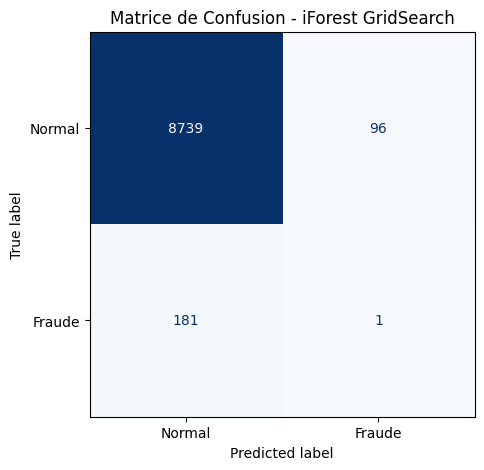


🔹 ROC-AUC (iForest GridSearch) : 0.4803


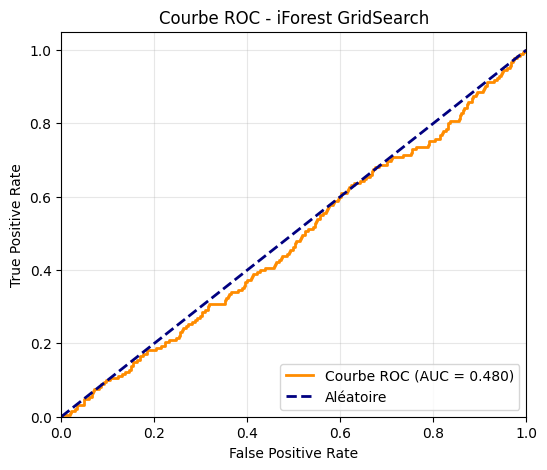


🔹 AUPRC / Average Precision (iForest GridSearch) : 0.0198

🔹 Métriques détaillées (iForest GridSearch)
  F1-score            : 0.0072
  F2-score            : 0.0061
  Precision@k (1%)    : 0.0111  (k = 90)
  Recall@k (1%)       : 0.0055
  Balanced accuracy   : 0.4973
  G-mean              : 0.0737
  MCC                 : -0.0073
  Kappa de Cohen      : -0.0070
  Indice de Jaccard   : 0.0036


In [61]:
# ---------- données du modèle GridSearch sur le test ----------
y_true_gs = y_test.values
y_pred_gs = y_pred_test_gs          # 0/1
y_score_gs = y_score_test_gs        # -decision_function

# 1) Matrice de confusion
cm_gs = confusion_matrix(y_true_gs, y_pred_gs)
print("\n🔹 MATRICE DE CONFUSION (iForest GridSearch)")
print("   (Réel en ligne, Prédit en colonne)")
print(f"   Réel=0 (N)  TN={cm_gs[0,0]:6d}   FP={cm_gs[0,1]:6d}")
print(f"   Réel=1 (F)  FN={cm_gs[1,0]:6d}   TP={cm_gs[1,1]:6d}")

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gs,
                              display_labels=['Normal', 'Fraude'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matrice de Confusion - iForest GridSearch')
plt.show()

# 2) Courbe ROC
roc_auc_gs = roc_auc_score(y_true_gs, y_score_gs)
print(f"\n🔹 ROC-AUC (iForest GridSearch) : {roc_auc_gs:.4f}")

fpr_gs, tpr_gs, _ = roc_curve(y_true_gs, y_score_gs)
plt.figure(figsize=(6, 5))
plt.plot(fpr_gs, tpr_gs, color='darkorange', lw=2,
         label=f'Courbe ROC (AUC = {roc_auc_gs:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, ls='--', label='Aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC - iForest GridSearch')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# 3) Métriques avancées
auprc_gs = average_precision_score(y_true_gs, y_score_gs)
prec_curve_gs, rec_curve_gs, _ = precision_recall_curve(y_true_gs, y_score_gs)

print(f"\n🔹 AUPRC / Average Precision (iForest GridSearch) : {auprc_gs:.4f}")

f1_gs = f1_score(y_true_gs, y_pred_gs, zero_division=0)
f2_gs = fbeta_score(y_true_gs, y_pred_gs, beta=2, zero_division=0)

k_gs = max(1, int(len(y_true_gs) * 0.01))
p_k_gs, r_k_gs = precision_recall_at_k(y_true_gs, y_score_gs, k_gs)

bal_acc_gs = balanced_accuracy_score(y_true_gs, y_pred_gs)
tn, fp, fn, tp = cm_gs.ravel()
sensitivity_gs = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity_gs = tn / (tn + fp) if (tn + fp) > 0 else 0.0
gmean_gs = np.sqrt(sensitivity_gs * specificity_gs)

mcc_gs = matthews_corrcoef(y_true_gs, y_pred_gs)
kappa_gs = cohen_kappa_score(y_true_gs, y_pred_gs)
jacc_gs = jaccard_score(y_true_gs, y_pred_gs)

print("\n🔹 Métriques détaillées (iForest GridSearch)")
print(f"  F1-score            : {f1_gs:.4f}")
print(f"  F2-score            : {f2_gs:.4f}")
print(f"  Precision@k (1%)    : {p_k_gs:.4f}  (k = {k_gs})")
print(f"  Recall@k (1%)       : {r_k_gs:.4f}")
print(f"  Balanced accuracy   : {bal_acc_gs:.4f}")
print(f"  G-mean              : {gmean_gs:.4f}")
print(f"  MCC                 : {mcc_gs:.4f}")
print(f"  Kappa de Cohen      : {kappa_gs:.4f}")
print(f"  Indice de Jaccard   : {jacc_gs:.4f}")


2. Optuna

In [62]:
best_params = study.best_params
mean_metrics = study.best_trial.user_attrs["mean_metrics"]

# Recréer le pipeline optimal
best_scaler = StandardScaler(
    with_mean=best_params['scaler_with_mean'],
    with_std=best_params['scaler_with_std']
)
iforest_optuna = IsolationForest(
    n_estimators=best_params['iforest_n_estimators'],
    max_samples=best_params['iforest_max_samples'],
    contamination=best_params['iforest_contamination'],
    max_features=best_params['iforest_max_features'],
    bootstrap=best_params['iforest_bootstrap'],
    random_state=42,
    n_jobs=-1
)

best_pipeline = Pipeline([
    ('scaler', best_scaler),
    ('iforest', iforest_optuna)
])

# IMPORTANT : mêmes features que dans Optuna (X_train_features)
best_pipeline.fit(X_train_features.values, y_train.values)

# Évaluation sur le test : mêmes colonnes que X_train_features
X_test_features = X_test[X_train_features.columns].values

X_test_scaled = best_scaler.transform(X_test_features)
scores_test = iforest_optuna.decision_function(X_test_scaled)
y_score_test = -scores_test
y_pred_if_test = iforest_optuna.predict(X_test_scaled)
y_pred_test = np.where(y_pred_if_test == -1, 1, 0)

test_metrics = compute_metrics(y_test.values, y_pred_test, y_score_test)
print("Métriques test (iForest Optuna) :", test_metrics)


Métriques test (iForest Optuna) : {'auprc': np.float64(0.020213557865548203), 'f1': 0.03593429158110883, 'f2': 0.07016840417000803, 'p_k': np.float64(0.011111111111111112), 'r_k': np.float64(0.005494505494505495), 'bal_acc': np.float64(0.49819119759697006), 'gmean': np.float64(0.3932298952966924), 'jaccard': np.float64(0.018295870360690015), 'mcc': np.float64(-0.0012819343673970865), 'kappa': np.float64(-0.0006874955236562119)}


In [63]:
nb_differences = (y_test != y_pred_test).sum()
print(f"Nombre de lignes différentes : {nb_differences}","soit", round(nb_differences/len(y_test)*100,2),"% des données de test")

Nombre de lignes différentes : 1878 soit 20.83 % des données de test


In [64]:
# y_test et y_pred_test doivent être des Series/arrays alignés
nb_fn = ((y_test == 1) & (y_pred_test == 0)).sum()
print("Nombre de fraudes manquées (FN) :", nb_fn)
pct_fn = (nb_fn / (y_test==1).sum()) * 100
print(f"Fraudes manquées : {nb_fn} soit {pct_fn:.2f} % des données de fraudes")



Nombre de fraudes manquées (FN) : 147
Fraudes manquées : 147 soit 80.77 % des données de fraudes



🔹 MATRICE DE CONFUSION (iForest Optuna)
   (Réel en ligne, Prédit en colonne)
   Réel=0 (N)  TN=  7104   FP=  1731
   Réel=1 (F)  FN=   147   TP=    35


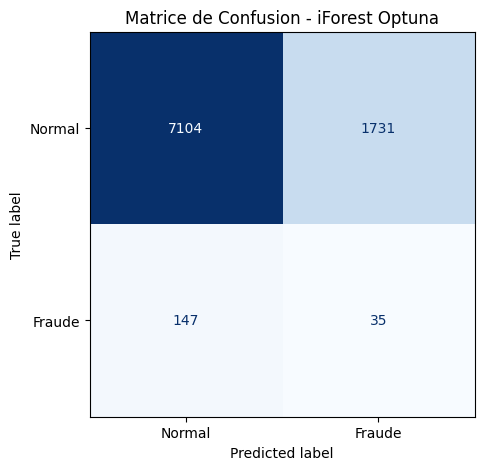


🔹 ROC-AUC (iForest Optuna) : 0.4888


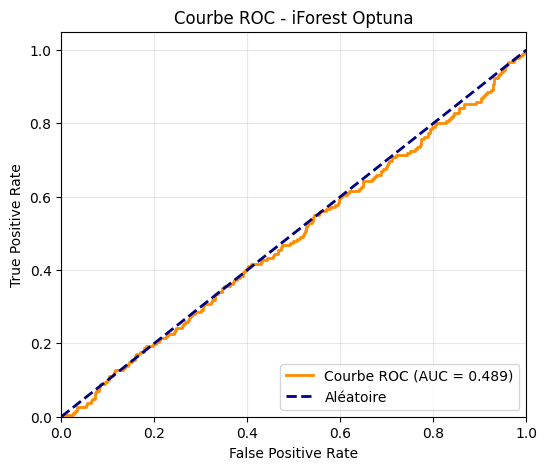


🔹 AUPRC / Average Precision (iForest Optuna) : 0.0202

🔹 Métriques détaillées (iForest Optuna)
  F1-score            : 0.0359
  F2-score            : 0.0702
  Precision@k (1%)    : 0.0111  (k = 90)
  Recall@k (1%)       : 0.0055
  Balanced accuracy   : 0.4982
  G-mean              : 0.3932
  MCC                 : -0.0013
  Kappa de Cohen      : -0.0007
  Indice de Jaccard   : 0.0183


In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    f1_score, fbeta_score, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score, jaccard_score
)

# ---------- fonctions utilitaires si besoin ----------
def precision_recall_at_k(y_true, y_score, k):
    idx = np.argsort(-y_score)
    top_k = idx[:k]
    y_top = y_true[top_k]
    precision_k = y_top.mean()
    recall_k = y_top.sum() / y_true.sum() if y_true.sum() > 0 else 0.0
    return precision_k, recall_k

# ---------- données du modèle Optuna sur le test ----------
y_true_opt = y_test.values
y_pred_opt = y_pred_test          # déjà 0/1
y_score_opt = y_score_test        # déjà -decision_function, plus grand = plus anormal

# 1) Matrice de confusion
cm_opt = confusion_matrix(y_true_opt, y_pred_opt)
print("\n🔹 MATRICE DE CONFUSION (iForest Optuna)")
print("   (Réel en ligne, Prédit en colonne)")
print(f"   Réel=0 (N)  TN={cm_opt[0,0]:6d}   FP={cm_opt[0,1]:6d}")
print(f"   Réel=1 (F)  FN={cm_opt[1,0]:6d}   TP={cm_opt[1,1]:6d}")

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_opt,
                              display_labels=['Normal', 'Fraude'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matrice de Confusion - iForest Optuna')
plt.show()

# 2) Courbe ROC
roc_auc_opt = roc_auc_score(y_true_opt, y_score_opt)
print(f"\n🔹 ROC-AUC (iForest Optuna) : {roc_auc_opt:.4f}")

fpr_opt, tpr_opt, _ = roc_curve(y_true_opt, y_score_opt)
plt.figure(figsize=(6, 5))
plt.plot(fpr_opt, tpr_opt, color='darkorange', lw=2,
         label=f'Courbe ROC (AUC = {roc_auc_opt:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, ls='--', label='Aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC - iForest Optuna')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# 3) Métriques avancées + Precision@k / Recall@k
auprc_opt = average_precision_score(y_true_opt, y_score_opt)
prec_curve, rec_curve, _ = precision_recall_curve(y_true_opt, y_score_opt)

print(f"\n🔹 AUPRC / Average Precision (iForest Optuna) : {auprc_opt:.4f}")

# F1 et F2
f1_opt = f1_score(y_true_opt, y_pred_opt, zero_division=0)
f2_opt = fbeta_score(y_true_opt, y_pred_opt, beta=2, zero_division=0)

# Precision@k / Recall@k (k = 1 % du test, min 1)
k_opt = max(1, int(len(y_true_opt) * 0.01))
p_k_opt, r_k_opt = precision_recall_at_k(y_true_opt, y_score_opt, k_opt)

# Balanced accuracy et G-mean
bal_acc_opt = balanced_accuracy_score(y_true_opt, y_pred_opt)
tn, fp, fn, tp = cm_opt.ravel()
sensitivity_opt = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity_opt = tn / (tn + fp) if (tn + fp) > 0 else 0.0
gmean_opt = np.sqrt(sensitivity_opt * specificity_opt)

# MCC, Kappa, Jaccard
mcc_opt = matthews_corrcoef(y_true_opt, y_pred_opt)
kappa_opt = cohen_kappa_score(y_true_opt, y_pred_opt)
jacc_opt = jaccard_score(y_true_opt, y_pred_opt)

print("\n🔹 Métriques détaillées (iForest Optuna)")
print(f"  F1-score            : {f1_opt:.4f}")
print(f"  F2-score            : {f2_opt:.4f}")
print(f"  Precision@k (1%)    : {p_k_opt:.4f}  (k = {k_opt})")
print(f"  Recall@k (1%)       : {r_k_opt:.4f}")
print(f"  Balanced accuracy   : {bal_acc_opt:.4f}")
print(f"  G-mean              : {gmean_opt:.4f}")
print(f"  MCC                 : {mcc_opt:.4f}")
print(f"  Kappa de Cohen      : {kappa_opt:.4f}")
print(f"  Indice de Jaccard   : {jacc_opt:.4f}")


3. RandomSearchCV

In [66]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import numpy as np

# 0) Colonnes dérivées à exclure pour tous les iForest
cols_iforest_deriv = ["iforest_anomaly_score", "iforest_anomaly_label"]
cols_iforest_deriv = [c for c in cols_iforest_deriv if c in X_train.columns]

X_train_clean = X_train.drop(columns=cols_iforest_deriv, errors="ignore").copy()
X_test_clean  = X_test.drop(columns=cols_iforest_deriv, errors="ignore").copy()

# ------------------------------------------------------------------
# 1) RandomizedSearch : ré‑entraînement + évaluation
# ------------------------------------------------------------------
# best_pipeline_rand et y_train, y_test existent déjà (RandomizedSearch fait plus haut)

scaler_rand: StandardScaler   = best_pipeline_rand.named_steps["scaler"]
iforest_randomsearch: IsolationForest = best_pipeline_rand.named_steps["iforest"]

# IMPORTANT : mêmes features que pendant RandomizedSearch
X_train_features_rs = X_train_clean.copy()
X_test_features_rs  = X_test_clean[X_train_features_rs.columns].copy()

# Entraînement final
best_pipeline_rand.fit(X_train_features_rs.values, y_train.values)

# Évaluation sur le test
X_test_scaled_rs = scaler_rand.transform(X_test_features_rs.values)
scores_test_rs   = iforest_randomsearch.decision_function(X_test_scaled_rs)
y_score_test_rs  = -scores_test_rs
y_pred_if_rs     = iforest_randomsearch.predict(X_test_scaled_rs)
y_pred_test_rs   = np.where(y_pred_if_rs == -1, 1, 0)

test_metrics_rs = compute_metrics(y_test.values, y_pred_test_rs, y_score_test_rs)
print("Métriques test (iForest RandomSearch) :", test_metrics_rs)

# ------------------------------------------------------------------
# 2) GridSearch : ré‑entraînement + évaluation
# ------------------------------------------------------------------
# grid_search existe déjà (défini plus haut)

grid_search.fit(X_train_clean, y_train)

best_pipeline_grid = grid_search.best_estimator_
scaler_grid        = best_pipeline_grid.named_steps["scaler"]
iforest_gridsearch = best_pipeline_grid.named_steps["iforest"]

# IMPORTANT : mêmes features que pendant GridSearch
X_train_features_gs = X_train_clean.copy()
X_test_features_gs  = X_test_clean[X_train_features_gs.columns].copy()

# Entraînement final
best_pipeline_grid.fit(X_train_features_gs.values, y_train.values)

# Évaluation sur le test
X_test_scaled_gs = scaler_grid.transform(X_test_features_gs.values)
scores_test_gs   = iforest_gridsearch.decision_function(X_test_scaled_gs)
y_score_test_gs  = -scores_test_gs
y_pred_if_gs     = iforest_gridsearch.predict(X_test_scaled_gs)
y_pred_test_gs   = np.where(y_pred_if_gs == -1, 1, 0)

test_metrics_gs = compute_metrics(y_test.values, y_pred_test_gs, y_score_test_gs)
print("Métriques test (iForest GridSearch) :", test_metrics_gs)



Métriques test (iForest RandomSearch) : {'auprc': np.float64(0.01941311375494071), 'f1': 0.03253012048192771, 'f2': 0.06119673617407072, 'p_k': np.float64(0.022222222222222223), 'r_k': np.float64(0.01098901098901099), 'bal_acc': np.float64(0.492059242398801), 'gmean': np.float64(0.3521184286918248), 'jaccard': np.float64(0.01653398652786283), 'mcc': np.float64(-0.0060330485032953195), 'kappa': np.float64(-0.003539375815822421)}
Fitting 5 folds for each of 144 candidates, totalling 720 fits
Métriques test (iForest GridSearch) : {'auprc': np.float64(0.019838956640363153), 'f1': 0.007168458781362007, 'f2': 0.006060606060606061, 'p_k': np.float64(0.011111111111111112), 'r_k': np.float64(0.005494505494505495), 'bal_acc': np.float64(0.4973143155655889), 'gmean': np.float64(0.07372111561902454), 'jaccard': np.float64(0.0035971223021582736), 'mcc': np.float64(-0.007322437177529924), 'kappa': np.float64(-0.006964101054855343)}


In [67]:
nb_diff_rs = (y_test.values != y_pred_test_rs).sum()
pct_diff_rs = nb_diff_rs / len(y_test) * 100

print(f"[RandomSearch] Nombre de lignes différentes : {nb_diff_rs} soit {pct_diff_rs:.2f} % des données de test")

nb_fn_rs = ((y_test.values == 1) & (y_pred_test_rs == 0)).sum()
pct_fn_rs = nb_fn_rs / (y_test.values == 1).sum() * 100

print(f"[RandomSearch] Nombre de fraudes manquées (FN) : {nb_fn_rs}")
print(f"[RandomSearch] Fraudes manquées : {nb_fn_rs} soit {pct_fn_rs:.2f} % des données de fraudes")


[RandomSearch] Nombre de lignes différentes : 1606 soit 17.81 % des données de test
[RandomSearch] Nombre de fraudes manquées (FN) : 155
[RandomSearch] Fraudes manquées : 155 soit 85.16 % des données de fraudes



🔹 MATRICE DE CONFUSION (iForest RandomSearch)
   (Réel en ligne, Prédit en colonne)
   Réel=0 (N)  TN=  7384   FP=  1451
   Réel=1 (F)  FN=   155   TP=    27


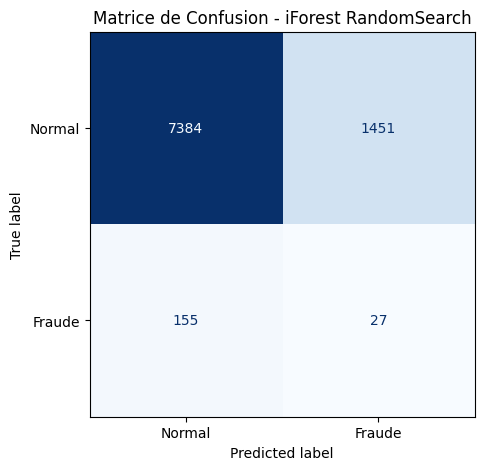


🔹 ROC-AUC (iForest RandomSearch) : 0.4808


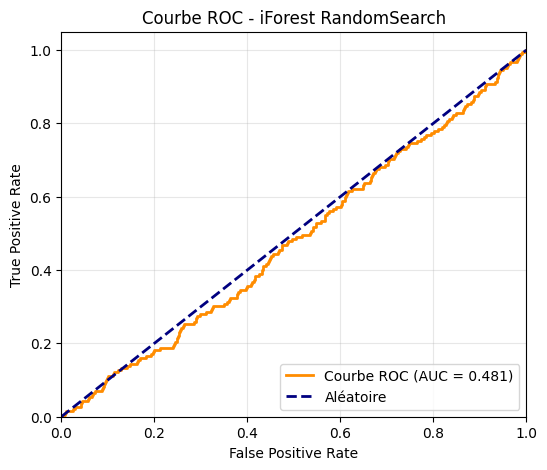


🔹 AUPRC / Average Precision (iForest RandomSearch) : 0.0194

🔹 Métriques détaillées (iForest RandomSearch)
  F1-score            : 0.0325
  F2-score            : 0.0612
  Precision@k (1%)    : 0.0222  (k = 90)
  Recall@k (1%)       : 0.0110
  Balanced accuracy   : 0.4921
  G-mean              : 0.3521
  MCC                 : -0.0060
  Kappa de Cohen      : -0.0035
  Indice de Jaccard   : 0.0165


In [68]:
# ---------- données du modèle RandomSearch sur le test ----------
y_true_rs = y_test.values
y_pred_rs = y_pred_test_rs          # 0/1
y_score_rs = y_score_test_rs        # -decision_function

# 1) Matrice de confusion
cm_rs = confusion_matrix(y_true_rs, y_pred_rs)
print("\n🔹 MATRICE DE CONFUSION (iForest RandomSearch)")
print("   (Réel en ligne, Prédit en colonne)")
print(f"   Réel=0 (N)  TN={cm_rs[0,0]:6d}   FP={cm_rs[0,1]:6d}")
print(f"   Réel=1 (F)  FN={cm_rs[1,0]:6d}   TP={cm_rs[1,1]:6d}")

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rs,
                              display_labels=['Normal', 'Fraude'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matrice de Confusion - iForest RandomSearch')
plt.show()

# 2) Courbe ROC
roc_auc_rs = roc_auc_score(y_true_rs, y_score_rs)
print(f"\n🔹 ROC-AUC (iForest RandomSearch) : {roc_auc_rs:.4f}")

fpr_rs, tpr_rs, _ = roc_curve(y_true_rs, y_score_rs)
plt.figure(figsize=(6, 5))
plt.plot(fpr_rs, tpr_rs, color='darkorange', lw=2,
         label=f'Courbe ROC (AUC = {roc_auc_rs:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, ls='--', label='Aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC - iForest RandomSearch')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# 3) Métriques avancées
auprc_rs = average_precision_score(y_true_rs, y_score_rs)
prec_curve_rs, rec_curve_rs, _ = precision_recall_curve(y_true_rs, y_score_rs)

print(f"\n🔹 AUPRC / Average Precision (iForest RandomSearch) : {auprc_rs:.4f}")

f1_rs = f1_score(y_true_rs, y_pred_rs, zero_division=0)
f2_rs = fbeta_score(y_true_rs, y_pred_rs, beta=2, zero_division=0)

k_rs = max(1, int(len(y_true_rs) * 0.01))
p_k_rs, r_k_rs = precision_recall_at_k(y_true_rs, y_score_rs, k_rs)

bal_acc_rs = balanced_accuracy_score(y_true_rs, y_pred_rs)
tn, fp, fn, tp = cm_rs.ravel()
sensitivity_rs = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity_rs = tn / (tn + fp) if (tn + fp) > 0 else 0.0
gmean_rs = np.sqrt(sensitivity_rs * specificity_rs)

mcc_rs = matthews_corrcoef(y_true_rs, y_pred_rs)
kappa_rs = cohen_kappa_score(y_true_rs, y_pred_rs)
jacc_rs = jaccard_score(y_true_rs, y_pred_rs)

print("\n🔹 Métriques détaillées (iForest RandomSearch)")
print(f"  F1-score            : {f1_rs:.4f}")
print(f"  F2-score            : {f2_rs:.4f}")
print(f"  Precision@k (1%)    : {p_k_rs:.4f}  (k = {k_rs})")
print(f"  Recall@k (1%)       : {r_k_rs:.4f}")
print(f"  Balanced accuracy   : {bal_acc_rs:.4f}")
print(f"  G-mean              : {gmean_rs:.4f}")
print(f"  MCC                 : {mcc_rs:.4f}")
print(f"  Kappa de Cohen      : {kappa_rs:.4f}")
print(f"  Indice de Jaccard   : {jacc_rs:.4f}")


Comparaisons entre modèles

In [69]:
import pandas as pd

results = pd.DataFrame([
    {
        "Model": "iForest_Optuna",
        "AUPRC": auprc_opt,
        "ROC_AUC": roc_auc_opt,
        "F1": f1_opt,
        "F2": f2_opt,
        "Precision@k": p_k_opt,
        "Recall@k": r_k_opt,
        "Balanced_Acc": bal_acc_opt,
        "Gmean": gmean_opt,
        "MCC": mcc_opt,
        "Kappa": kappa_opt,
        "Jaccard": jacc_opt
    },
    {
        "Model": "iForest_GridSearch",
        "AUPRC": auprc_gs,
        "ROC_AUC": roc_auc_gs,
        "F1": f1_gs,
        "F2": f2_gs,
        "Precision@k": p_k_gs,
        "Recall@k": r_k_gs,
        "Balanced_Acc": bal_acc_gs,
        "Gmean": gmean_gs,
        "MCC": mcc_gs,
        "Kappa": kappa_gs,
        "Jaccard": jacc_gs
    },
    {
        "Model": "iForest_RandomSearch",
        "AUPRC": auprc_rs,
        "ROC_AUC": roc_auc_rs,
        "F1": f1_rs,
        "F2": f2_rs,
        "Precision@k": p_k_rs,
        "Recall@k": r_k_rs,
        "Balanced_Acc": bal_acc_rs,
        "Gmean": gmean_rs,
        "MCC": mcc_rs,
        "Kappa": kappa_rs,
        "Jaccard": jacc_rs
    }
])

results


,Model,AUPRC,ROC_AUC,F1,F2,Precision@k,Recall@k,Balanced_Acc,Gmean,MCC,Kappa,Jaccard
0,iForest_Optuna,0.020214,0.488757,0.035934,0.070168,0.011111,0.005495,0.498191,0.393230,-0.001282,-0.000687,0.018296
1,iForest_GridSearch,0.019839,0.480347,0.007168,0.006061,0.011111,0.005495,0.497314,0.073721,-0.007322,-0.006964,0.003597
2,iForest_RandomSearch,0.019413,0.480839,0.032530,0.061197,0.022222,0.010989,0.492059,0.352118,-0.006033,-0.003539,0.016534


In [70]:
import plotly.express as px

metrics_to_plot = ["AUPRC", "F1", "F2", "Recall@k", "Balanced_Acc", "Gmean"]

df_melt = results.melt(
    id_vars="Model",
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Score"
)

fig = px.bar(
    df_melt,
    x="Model",
    y="Score",
    color="Metric",
    barmode="group",
    text="Score",
    title="Comparaison des performances iForest (Optuna / Grid / Random)",
)

fig.update_traces(texttemplate="%{text:.3f}", textposition="outside")
fig.update_layout(yaxis=dict(title="Score", range=[0, 1]),
                  xaxis_title="Modèle",
                  legend_title="Métrique")
fig.show()


In [71]:
imb_metrics = ["MCC", "Kappa", "Jaccard"]

df_imb = results.melt(
    id_vars="Model",
    value_vars=imb_metrics,
    var_name="Metric",
    value_name="Score"
)

fig_imb = px.bar(
    df_imb,
    x="Model",
    y="Score",
    color="Metric",
    barmode="group",
    text="Score",
    title="Métriques robustes au déséquilibre (MCC, Kappa, Jaccard)",
)

fig_imb.update_traces(texttemplate="%{text:.3f}", textposition="outside")
fig_imb.update_layout(yaxis=dict(title="Score", range=[-0.05, 0.05]),
                      xaxis_title="Modèle",
                      legend_title="Métrique")
fig_imb.show()


In [72]:
import plotly.figure_factory as ff

fig_table = ff.create_table(
    results.round(4),
    index=False
)
fig_table.update_layout(title_text="Résumé des métriques sur le jeu de test")
fig_table.show()


## **CONCLUSION :** Optuna fournit les meilleurs résultats parmi les 3 méthodes d'optimisation des hyperparamètres et les résultats obtenus après apprentissage non supervisé sur iForest, ne sont pas extraordinaires et peuvent certainement être améliorés à l'aide d'autres méthodes.

# AMELIORATION DE L'ANOMALY DETECTION

### Modèles supervisés de base

Imports et fonction de métriques

In [73]:
!pip install xgboost imbalanced-learn

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    f1_score, fbeta_score,
    recall_score,
    precision_recall_curve
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [74]:
def compute_supervised_metrics(y_true, y_proba, y_pred, beta=2):
    """
    y_proba : proba prédite pour la classe 1 (fraude)
    y_pred  : prédiction binaire (0/1)
    """
    auprc = average_precision_score(y_true, y_proba)
    f1    = f1_score(y_true, y_pred, zero_division=0)
    f2    = fbeta_score(y_true, y_pred, beta=beta, zero_division=0)
    rec   = recall_score(y_true, y_pred, zero_division=0)

    return {
        "auprc": auprc,
        "f1": f1,
        "f2": f2,
        "recall": rec
    }


RandomForest avec class_weight

X_train_rf shape : (36065, 20)
X_test_rf  shape : (9017, 20)

Classification report (RandomForest class_weight) :
              precision    recall  f1-score   support

           0     0.9798    1.0000    0.9898      8835
           1     0.0000    0.0000    0.0000       182

    accuracy                         0.9798      9017
   macro avg     0.4899    0.5000    0.4949      9017
weighted avg     0.9600    0.9798    0.9698      9017


🔹 MATRICE DE CONFUSION (RandomForest class_weight)
   (Réel en ligne, Prédit en colonne)
   Réel=0 (N)  TN=  8835   FP=     0
   Réel=1 (F)  FN=   182   TP=     0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



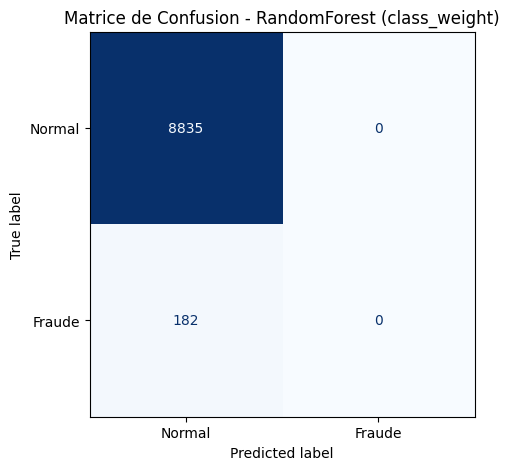


🔹 ROC-AUC (RandomForest) : 0.6492


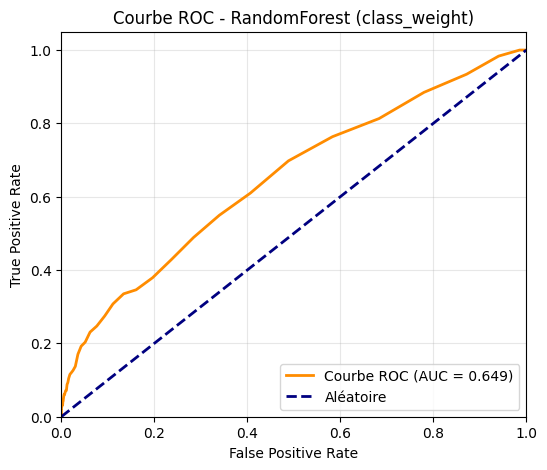


🔹 AUPRC / Average Precision (RandomForest) : 0.0664


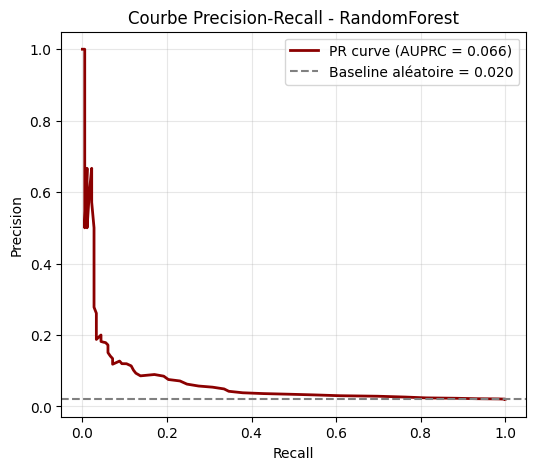


🔹 Métriques détaillées (RandomForest class_weight)
  F1-score            : 0.0000
  F2-score            : 0.0000
  Precision@k (1%)    : 0.1333  (k = 90)
  Recall@k (1%)       : 0.0659
  Balanced accuracy   : 0.5000
  G-mean              : 0.0000
  MCC                 : 0.0000
  Kappa de Cohen      : 0.0000
  Indice de Jaccard   : 0.0000


In [75]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    f1_score, fbeta_score, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score, jaccard_score,
    classification_report
)

# --------------------------------------------------
# 1) Fonctions utilitaires
# --------------------------------------------------
def precision_recall_at_k(y_true, y_score, k):
    """Precision@k et Recall@k en triant par score décroissant."""
    idx = np.argsort(-y_score)
    top_k = idx[:k]
    y_top = y_true[top_k]
    precision_k = y_top.mean()
    recall_k = y_top.sum() / y_true.sum() if y_true.sum() > 0 else 0.0
    return precision_k, recall_k


# --------------------------------------------------
# 2) Définition du modèle RandomForest (class_weight)
# --------------------------------------------------
rf_clf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=42,
    class_weight={0: 1.0, 1: 50.0}   # pondération forte de la fraude
)


# --------------------------------------------------
# 3) Préparation des features (on enlève les colonnes iForest)
# --------------------------------------------------
cols_to_drop = ['iforest_anomaly_score', 'iforest_anomaly_label']
cols_to_drop = [c for c in cols_to_drop if c in X_train.columns]

X_train_rf = X_train.drop(columns=cols_to_drop).copy()
X_test_rf  = X_test[X_train_rf.columns].copy()   # mêmes colonnes que le train

print(f"X_train_rf shape : {X_train_rf.shape}")
print(f"X_test_rf  shape : {X_test_rf.shape}")

# --------------------------------------------------
# 4) Entraînement du modèle
# --------------------------------------------------
rf_clf.fit(X_train_rf, y_train)

# --------------------------------------------------
# 5) Prédictions probas et labels sur le test
# --------------------------------------------------
y_true_rf  = y_test.values
y_proba_rf = rf_clf.predict_proba(X_test_rf)[:, 1]   # proba classe 1
y_pred_rf  = (y_proba_rf >= 0.5).astype(int)        # seuil 0.5 (à ajuster si besoin)

print("\nClassification report (RandomForest class_weight) :")
print(classification_report(y_true_rf, y_pred_rf, digits=4))

# --------------------------------------------------
# 6) Matrice de confusion
# --------------------------------------------------
cm_rf = confusion_matrix(y_true_rf, y_pred_rf)

print("\n🔹 MATRICE DE CONFUSION (RandomForest class_weight)")
print("   (Réel en ligne, Prédit en colonne)")
print(f"   Réel=0 (N)  TN={cm_rf[0,0]:6d}   FP={cm_rf[0,1]:6d}")
print(f"   Réel=1 (F)  FN={cm_rf[1,0]:6d}   TP={cm_rf[1,1]:6d}")

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                              display_labels=['Normal', 'Fraude'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matrice de Confusion - RandomForest (class_weight)')
plt.show()

# --------------------------------------------------
# 7) Courbe ROC + AUC
# --------------------------------------------------
y_score_rf = y_proba_rf  # alias pour cohérence avec les autres modèles

roc_auc_rf = roc_auc_score(y_true_rf, y_score_rf)
print(f"\n🔹 ROC-AUC (RandomForest) : {roc_auc_rf:.4f}")

fpr_rf, tpr_rf, _ = roc_curve(y_true_rf, y_score_rf)

plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2,
         label=f'Courbe ROC (AUC = {roc_auc_rf:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, ls='--', label='Aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC - RandomForest (class_weight)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# --------------------------------------------------
# 8) AUPRC + courbe PR
# --------------------------------------------------
auprc_rf = average_precision_score(y_true_rf, y_score_rf)
prec_curve_rf, rec_curve_rf, _ = precision_recall_curve(y_true_rf, y_score_rf)

print(f"\n🔹 AUPRC / Average Precision (RandomForest) : {auprc_rf:.4f}")

plt.figure(figsize=(6, 5))
plt.plot(rec_curve_rf, prec_curve_rf, color='darkred', lw=2,
         label=f'PR curve (AUPRC = {auprc_rf:.3f})')
plt.axhline(y=y_true_rf.mean(), color='gray', ls='--',
            label=f'Baseline aléatoire = {y_true_rf.mean():.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall - RandomForest')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --------------------------------------------------
# 9) F1, F2, Precision@k, Recall@k
# --------------------------------------------------
f1_rf = f1_score(y_true_rf, y_pred_rf, zero_division=0)
f2_rf = fbeta_score(y_true_rf, y_pred_rf, beta=2, zero_division=0)

k_rf = max(1, int(len(y_true_rf) * 0.01))  # top 1% du test
p_k_rf, r_k_rf = precision_recall_at_k(y_true_rf, y_score_rf, k_rf)

# --------------------------------------------------
# 10) Balanced accuracy, G-mean
# --------------------------------------------------
bal_acc_rf = balanced_accuracy_score(y_true_rf, y_pred_rf)
tn, fp, fn, tp = cm_rf.ravel()
sensitivity_rf = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity_rf = tn / (tn + fp) if (tn + fp) > 0 else 0.0
gmean_rf = np.sqrt(sensitivity_rf * specificity_rf)

# --------------------------------------------------
# 11) MCC, Kappa, Jaccard
# --------------------------------------------------
mcc_rf = matthews_corrcoef(y_true_rf, y_pred_rf)
kappa_rf = cohen_kappa_score(y_true_rf, y_pred_rf)
jacc_rf = jaccard_score(y_true_rf, y_pred_rf)

print("\n🔹 Métriques détaillées (RandomForest class_weight)")
print(f"  F1-score            : {f1_rf:.4f}")
print(f"  F2-score            : {f2_rf:.4f}")
print(f"  Precision@k (1%)    : {p_k_rf:.4f}  (k = {k_rf})")
print(f"  Recall@k (1%)       : {r_k_rf:.4f}")
print(f"  Balanced accuracy   : {bal_acc_rf:.4f}")
print(f"  G-mean              : {gmean_rf:.4f}")
print(f"  MCC                 : {mcc_rf:.4f}")
print(f"  Kappa de Cohen      : {kappa_rf:.4f}")
print(f"  Indice de Jaccard   : {jacc_rf:.4f}")


XGBoost supervisé avec scale_pos_weight

In [76]:
# ratio négatifs / positifs dans le train
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos

xgb_clf = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

xgb_clf.fit(X_train, y_train)

y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]
y_pred_xgb  = (y_proba_xgb >= 0.5).astype(int)

metrics_xgb = compute_supervised_metrics(y_test, y_proba_xgb, y_pred_xgb)
print("Métriques XGBoost :", metrics_xgb)

print("\nClassification report (XGB) :")
print(classification_report(y_test, y_pred_xgb, digits=4))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("\nMatrice de confusion XGB :")
print(cm_xgb)


ValueError: feature_names mismatch: ['loan_amount_requested', 'loan_tenure_months', 'interest_rate_offered', 'cibil_score', 'debt_to_income_ratio', 'applicant_age', 'number_of_dependents', 'loan_type_Car Loan', 'loan_type_Education Loan', 'loan_type_Home Loan', 'loan_type_Personal Loan', 'employment_status_Retired', 'employment_status_Salaried', 'employment_status_Self-Employed', 'employment_status_Student', 'employment_status_Unemployed', 'property_ownership_status_Owned', 'property_ownership_status_Rented', 'gender_Male', 'gender_Other', 'iforest_anomaly_score', 'iforest_anomaly_label'] ['loan_amount_requested', 'loan_tenure_months', 'interest_rate_offered', 'cibil_score', 'debt_to_income_ratio', 'applicant_age', 'number_of_dependents', 'loan_type_Car Loan', 'loan_type_Education Loan', 'loan_type_Home Loan', 'loan_type_Personal Loan', 'employment_status_Retired', 'employment_status_Salaried', 'employment_status_Self-Employed', 'employment_status_Student', 'employment_status_Unemploye

### Gestion du déséquilibre (rééchantillonnage SMOTE)

In [77]:
import numpy as np
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    f1_score, fbeta_score, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score, jaccard_score,
    classification_report
)


RandomForest + SMOTE

X_train_sm shape : (36065, 20)
X_test_sm  shape : (9017, 20)

Classification report (RF + SMOTE) :
              precision    recall  f1-score   support

           0     0.9799    0.9791    0.9795      8835
           1     0.0263    0.0275    0.0269       182

    accuracy                         0.9599      9017
   macro avg     0.5031    0.5033    0.5032      9017
weighted avg     0.9607    0.9599    0.9603      9017


🔹 MATRICE DE CONFUSION (RandomForest + SMOTE)
   (Réel en ligne, Prédit en colonne)
   Réel=0 (N)  TN=  8650   FP=   185
   Réel=1 (F)  FN=   177   TP=     5


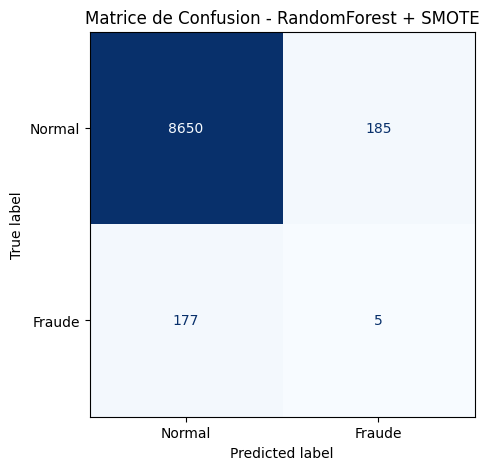


🔹 ROC-AUC (RandomForest + SMOTE) : 0.6052


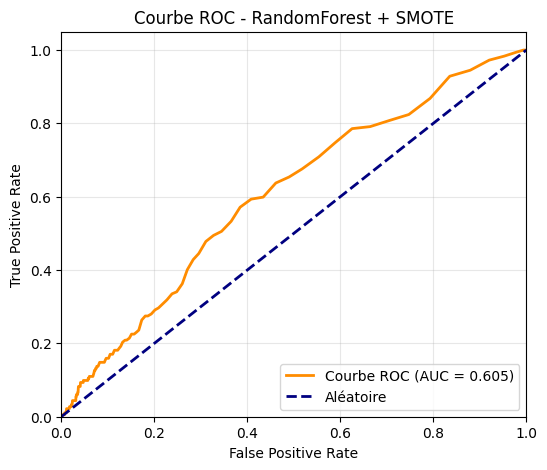


🔹 AUPRC / Average Precision (RF + SMOTE) : 0.0337


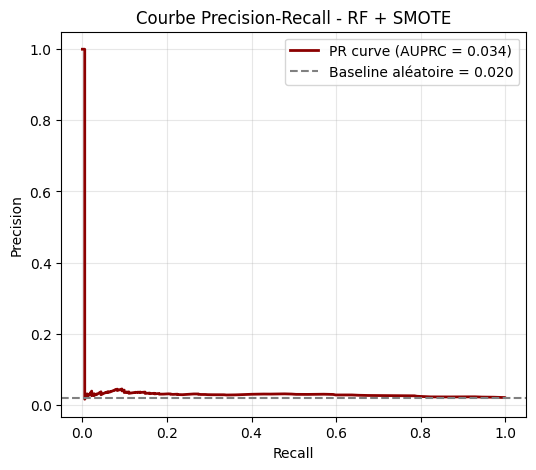


🔹 Métriques détaillées (RandomForest + SMOTE)
  F1-score            : 0.0269
  F2-score            : 0.0272
  Precision@k (1%)    : 0.0222  (k = 90)
  Recall@k (1%)       : 0.0110
  Balanced accuracy   : 0.5033
  G-mean              : 0.1640
  MCC                 : 0.0064
  Kappa de Cohen      : 0.0064
  Indice de Jaccard   : 0.0136

Nombre de lignes différentes : 362 soit 4.01 % des données de test
Nombre de fraudes manquées (FN) : 177
Fraudes manquées : 177 soit 97.25 % des données de fraudes


In [78]:
# --------------------------------------------------
# 1) Fonctions utilitaires
# --------------------------------------------------
def precision_recall_at_k(y_true, y_score, k):
    idx = np.argsort(-y_score)
    top_k = idx[:k]
    y_top = y_true[top_k]
    precision_k = y_top.mean()
    recall_k = y_top.sum() / y_true.sum() if y_true.sum() > 0 else 0.0
    return precision_k, recall_k


# --------------------------------------------------
# 2) SMOTE + RandomForest
# --------------------------------------------------
smote = SMOTE(
    sampling_strategy='auto',
    random_state=42,
    k_neighbors=5
)

rf_clf_smote = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
    class_weight=None        # SMOTE gère l'équilibre
)

pipe_rf_smote = ImbPipeline(steps=[
    ('smote', smote),
    ('rf', rf_clf_smote)
])

# IMPORTANT : mêmes features que pour les autres modèles supervisés
cols_to_drop = ['iforest_anomaly_score', 'iforest_anomaly_label']
cols_to_drop = [c for c in cols_to_drop if c in X_train.columns]

X_train_sm = X_train.drop(columns=cols_to_drop).copy()
X_test_sm  = X_test[X_train_sm.columns].copy()

print(f"X_train_sm shape : {X_train_sm.shape}")
print(f"X_test_sm  shape : {X_test_sm.shape}")

# --------------------------------------------------
# 3) Entraînement
# --------------------------------------------------
pipe_rf_smote.fit(X_train_sm, y_train)

# --------------------------------------------------
# 4) Prédictions test
# --------------------------------------------------
y_true_rf_sm = y_test.values
y_proba_rf_smote = pipe_rf_smote.predict_proba(X_test_sm)[:, 1]
y_pred_rf_smote  = (y_proba_rf_smote >= 0.5).astype(int)

print("\nClassification report (RF + SMOTE) :")
print(classification_report(y_true_rf_sm, y_pred_rf_smote, digits=4))

# --------------------------------------------------
# 5) Matrice de confusion
# --------------------------------------------------
cm_rf_sm = confusion_matrix(y_true_rf_sm, y_pred_rf_smote)

print("\n🔹 MATRICE DE CONFUSION (RandomForest + SMOTE)")
print("   (Réel en ligne, Prédit en colonne)")
print(f"   Réel=0 (N)  TN={cm_rf_sm[0,0]:6d}   FP={cm_rf_sm[0,1]:6d}")
print(f"   Réel=1 (F)  FN={cm_rf_sm[1,0]:6d}   TP={cm_rf_sm[1,1]:6d}")

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf_sm,
                              display_labels=['Normal', 'Fraude'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matrice de Confusion - RandomForest + SMOTE')
plt.show()

# --------------------------------------------------
# 6) Courbe ROC + AUC
# --------------------------------------------------
y_score_rf_sm = y_proba_rf_smote

roc_auc_rf_sm = roc_auc_score(y_true_rf_sm, y_score_rf_sm)
print(f"\n🔹 ROC-AUC (RandomForest + SMOTE) : {roc_auc_rf_sm:.4f}")

fpr_rf_sm, tpr_rf_sm, _ = roc_curve(y_true_rf_sm, y_score_rf_sm)

plt.figure(figsize=(6, 5))
plt.plot(fpr_rf_sm, tpr_rf_sm, color='darkorange', lw=2,
         label=f'Courbe ROC (AUC = {roc_auc_rf_sm:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, ls='--', label='Aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC - RandomForest + SMOTE')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# --------------------------------------------------
# 7) AUPRC + courbe PR
# --------------------------------------------------
auprc_rf_sm = average_precision_score(y_true_rf_sm, y_score_rf_sm)
prec_curve_rf_sm, rec_curve_rf_sm, _ = precision_recall_curve(y_true_rf_sm, y_score_rf_sm)

print(f"\n🔹 AUPRC / Average Precision (RF + SMOTE) : {auprc_rf_sm:.4f}")

plt.figure(figsize=(6, 5))
plt.plot(rec_curve_rf_sm, prec_curve_rf_sm, color='darkred', lw=2,
         label=f'PR curve (AUPRC = {auprc_rf_sm:.3f})')
plt.axhline(y=y_true_rf_sm.mean(), color='gray', ls='--',
            label=f'Baseline aléatoire = {y_true_rf_sm.mean():.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall - RF + SMOTE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --------------------------------------------------
# 8) F1, F2, Precision@k, Recall@k
# --------------------------------------------------
f1_rf_sm = f1_score(y_true_rf_sm, y_pred_rf_smote, zero_division=0)
f2_rf_sm = fbeta_score(y_true_rf_sm, y_pred_rf_smote, beta=2, zero_division=0)

k_rf_sm = max(1, int(len(y_true_rf_sm) * 0.01))  # top 1% du test
p_k_rf_sm, r_k_rf_sm = precision_recall_at_k(y_true_rf_sm, y_score_rf_sm, k_rf_sm)

# --------------------------------------------------
# 9) Balanced accuracy, G-mean
# --------------------------------------------------
bal_acc_rf_sm = balanced_accuracy_score(y_true_rf_sm, y_pred_rf_smote)
tn, fp, fn, tp = cm_rf_sm.ravel()
sensitivity_rf_sm = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity_rf_sm = tn / (tn + fp) if (tn + fp) > 0 else 0.0
gmean_rf_sm = np.sqrt(sensitivity_rf_sm * specificity_rf_sm)

# --------------------------------------------------
# 10) MCC, Kappa, Jaccard
# --------------------------------------------------
mcc_rf_sm = matthews_corrcoef(y_true_rf_sm, y_pred_rf_smote)
kappa_rf_sm = cohen_kappa_score(y_true_rf_sm, y_pred_rf_smote)
jacc_rf_sm = jaccard_score(y_true_rf_sm, y_pred_rf_smote)

print("\n🔹 Métriques détaillées (RandomForest + SMOTE)")
print(f"  F1-score            : {f1_rf_sm:.4f}")
print(f"  F2-score            : {f2_rf_sm:.4f}")
print(f"  Precision@k (1%)    : {p_k_rf_sm:.4f}  (k = {k_rf_sm})")
print(f"  Recall@k (1%)       : {r_k_rf_sm:.4f}")
print(f"  Balanced accuracy   : {bal_acc_rf_sm:.4f}")
print(f"  G-mean              : {gmean_rf_sm:.4f}")
print(f"  MCC                 : {mcc_rf_sm:.4f}")
print(f"  Kappa de Cohen      : {kappa_rf_sm:.4f}")
print(f"  Indice de Jaccard   : {jacc_rf_sm:.4f}")

# --------------------------------------------------
# 11) Nombre de lignes différentes et fraudes manquées (FN)
#     comme sur ta capture
# --------------------------------------------------
nb_diff_rf_sm = (y_test.values != y_pred_rf_smote).sum()
pct_diff_rf_sm = nb_diff_rf_sm / len(y_test) * 100

print(f"\nNombre de lignes différentes : {nb_diff_rf_sm} "
      f"soit {pct_diff_rf_sm:.2f} % des données de test")

nb_fn_rf_sm = ((y_test.values == 1) & (y_pred_rf_smote == 0)).sum()
pct_fn_rf_sm = nb_fn_rf_sm / (y_test.values == 1).sum() * 100

print(f"Nombre de fraudes manquées (FN) : {nb_fn_rf_sm}")
print(f"Fraudes manquées : {nb_fn_rf_sm} "
      f"soit {pct_fn_rf_sm:.2f} % des données de fraudes")


XGBoost + SMOTEENN (oversample + nettoyage)

X_train_xgb shape : (36065, 20)
X_test_xgb  shape : (9017, 20)

Classification report (XGB + SMOTEENN) :
              precision    recall  f1-score   support

           0     0.9801    0.9750    0.9775      8835
           1     0.0307    0.0385    0.0341       182

    accuracy                         0.9561      9017
   macro avg     0.5054    0.5067    0.5058      9017
weighted avg     0.9609    0.9561    0.9585      9017


🔹 MATRICE DE CONFUSION (XGB + SMOTEENN)
   (Réel en ligne, Prédit en colonne)
   Réel=0 (N)  TN=  8614   FP=   221
   Réel=1 (F)  FN=   175   TP=     7


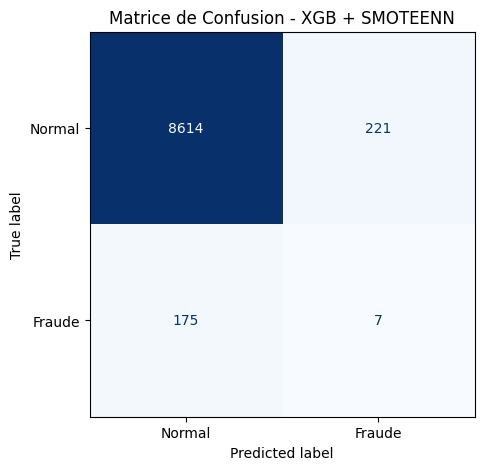


🔹 ROC-AUC (XGB + SMOTEENN) : 0.5487


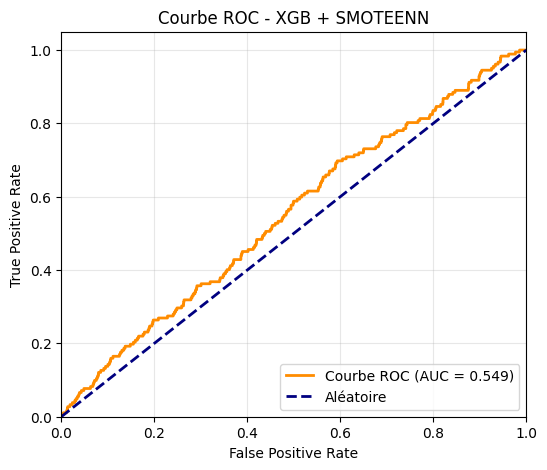


🔹 AUPRC / Average Precision (XGB + SMOTEENN) : 0.0252


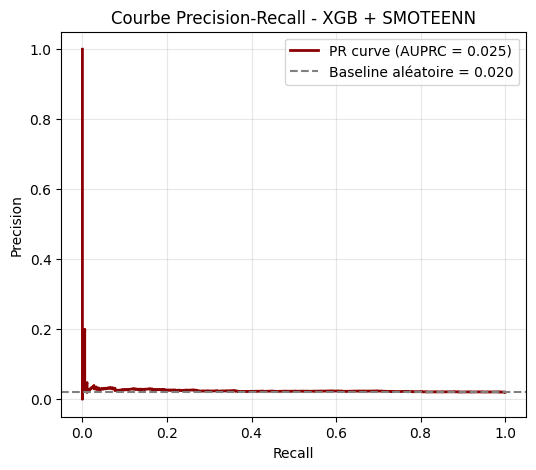


🔹 Métriques détaillées (XGB + SMOTEENN)
  F1-score            : 0.0341
  F2-score            : 0.0366
  Precision@k (1%)    : 0.0222  (k = 90)
  Recall@k (1%)       : 0.0110
  Balanced accuracy   : 0.5067
  G-mean              : 0.1936
  MCC                 : 0.0120
  Kappa de Cohen      : 0.0120
  Indice de Jaccard   : 0.0174

Nombre de lignes différentes : 396 soit 4.39 % des données de test
Nombre de fraudes manquées (FN) : 175
Fraudes manquées : 175 soit 96.15 % des données de fraudes


In [79]:
import numpy as np
import matplotlib.pyplot as plt

from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    f1_score, fbeta_score, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score, jaccard_score,
    classification_report
)

# --------------------------------------------------
# 1) Fonctions utilitaires (si pas déjà définies)
# --------------------------------------------------
def precision_recall_at_k(y_true, y_score, k):
    idx = np.argsort(-y_score)
    top_k = idx[:k]
    y_top = y_true[top_k]
    precision_k = y_top.mean()
    recall_k = y_top.sum() / y_true.sum() if y_true.sum() > 0 else 0.0
    return precision_k, recall_k


# --------------------------------------------------
# 2) SMOTEENN + XGBoost
# --------------------------------------------------
smoteenn = SMOTEENN(
    sampling_strategy='auto',
    random_state=42
)

xgb_clf_resamp = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=1.0   # déjà rééquilibré par SMOTEENN
)

pipe_xgb_smoteenn = ImbPipeline(steps=[
    ('smoteenn', smoteenn),
    ('xgb', xgb_clf_resamp)
])

# IMPORTANT : mêmes features que pour les autres modèles supervisés
cols_to_drop = ['iforest_anomaly_score', 'iforest_anomaly_label']
cols_to_drop = [c for c in cols_to_drop if c in X_train.columns]

X_train_xgb = X_train.drop(columns=cols_to_drop).copy()
X_test_xgb  = X_test[X_train_xgb.columns].copy()

print(f"X_train_xgb shape : {X_train_xgb.shape}")
print(f"X_test_xgb  shape : {X_test_xgb.shape}")

# --------------------------------------------------
# 3) Entraînement
# --------------------------------------------------
pipe_xgb_smoteenn.fit(X_train_xgb, y_train)

# --------------------------------------------------
# 4) Prédictions test
# --------------------------------------------------
y_true_xgb_sm = y_test.values
y_proba_xgb_smoteenn = pipe_xgb_smoteenn.predict_proba(X_test_xgb)[:, 1]
y_pred_xgb_smoteenn  = (y_proba_xgb_smoteenn >= 0.5).astype(int)

print("\nClassification report (XGB + SMOTEENN) :")
print(classification_report(y_true_xgb_sm, y_pred_xgb_smoteenn, digits=4))

# --------------------------------------------------
# 5) Matrice de confusion
# --------------------------------------------------
cm_xgb_sm = confusion_matrix(y_true_xgb_sm, y_pred_xgb_smoteenn)

print("\n🔹 MATRICE DE CONFUSION (XGB + SMOTEENN)")
print("   (Réel en ligne, Prédit en colonne)")
print(f"   Réel=0 (N)  TN={cm_xgb_sm[0,0]:6d}   FP={cm_xgb_sm[0,1]:6d}")
print(f"   Réel=1 (F)  FN={cm_xgb_sm[1,0]:6d}   TP={cm_xgb_sm[1,1]:6d}")

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_sm,
                              display_labels=['Normal', 'Fraude'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matrice de Confusion - XGB + SMOTEENN')
plt.show()

# --------------------------------------------------
# 6) Courbe ROC + AUC
# --------------------------------------------------
y_score_xgb_sm = y_proba_xgb_smoteenn

roc_auc_xgb_sm = roc_auc_score(y_true_xgb_sm, y_score_xgb_sm)
print(f"\n🔹 ROC-AUC (XGB + SMOTEENN) : {roc_auc_xgb_sm:.4f}")

fpr_xgb_sm, tpr_xgb_sm, _ = roc_curve(y_true_xgb_sm, y_score_xgb_sm)

plt.figure(figsize=(6, 5))
plt.plot(fpr_xgb_sm, tpr_xgb_sm, color='darkorange', lw=2,
         label=f'Courbe ROC (AUC = {roc_auc_xgb_sm:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, ls='--', label='Aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC - XGB + SMOTEENN')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# --------------------------------------------------
# 7) AUPRC + courbe PR
# --------------------------------------------------
auprc_xgb_sm = average_precision_score(y_true_xgb_sm, y_score_xgb_sm)
prec_curve_xgb_sm, rec_curve_xgb_sm, _ = precision_recall_curve(y_true_xgb_sm, y_score_xgb_sm)

print(f"\n🔹 AUPRC / Average Precision (XGB + SMOTEENN) : {auprc_xgb_sm:.4f}")

plt.figure(figsize=(6, 5))
plt.plot(rec_curve_xgb_sm, prec_curve_xgb_sm, color='darkred', lw=2,
         label=f'PR curve (AUPRC = {auprc_xgb_sm:.3f})')
plt.axhline(y=y_true_xgb_sm.mean(), color='gray', ls='--',
            label=f'Baseline aléatoire = {y_true_xgb_sm.mean():.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall - XGB + SMOTEENN')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --------------------------------------------------
# 8) F1, F2, Precision@k, Recall@k
# --------------------------------------------------
f1_xgb_sm = f1_score(y_true_xgb_sm, y_pred_xgb_smoteenn, zero_division=0)
f2_xgb_sm = fbeta_score(y_true_xgb_sm, y_pred_xgb_smoteenn, beta=2, zero_division=0)

k_xgb_sm = max(1, int(len(y_true_xgb_sm) * 0.01))  # top 1% du test
p_k_xgb_sm, r_k_xgb_sm = precision_recall_at_k(y_true_xgb_sm, y_score_xgb_sm, k_xgb_sm)

# --------------------------------------------------
# 9) Balanced accuracy, G-mean
# --------------------------------------------------
bal_acc_xgb_sm = balanced_accuracy_score(y_true_xgb_sm, y_pred_xgb_smoteenn)
tn, fp, fn, tp = cm_xgb_sm.ravel()
sensitivity_xgb_sm = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity_xgb_sm = tn / (tn + fp) if (tn + fp) > 0 else 0.0
gmean_xgb_sm = np.sqrt(sensitivity_xgb_sm * specificity_xgb_sm)

# --------------------------------------------------
# 10) MCC, Kappa, Jaccard
# --------------------------------------------------
mcc_xgb_sm = matthews_corrcoef(y_true_xgb_sm, y_pred_xgb_smoteenn)
kappa_xgb_sm = cohen_kappa_score(y_true_xgb_sm, y_pred_xgb_smoteenn)
jacc_xgb_sm = jaccard_score(y_true_xgb_sm, y_pred_xgb_smoteenn)

print("\n🔹 Métriques détaillées (XGB + SMOTEENN)")
print(f"  F1-score            : {f1_xgb_sm:.4f}")
print(f"  F2-score            : {f2_xgb_sm:.4f}")
print(f"  Precision@k (1%)    : {p_k_xgb_sm:.4f}  (k = {k_xgb_sm})")
print(f"  Recall@k (1%)       : {r_k_xgb_sm:.4f}")
print(f"  Balanced accuracy   : {bal_acc_xgb_sm:.4f}")
print(f"  G-mean              : {gmean_xgb_sm:.4f}")
print(f"  MCC                 : {mcc_xgb_sm:.4f}")
print(f"  Kappa de Cohen      : {kappa_xgb_sm:.4f}")
print(f"  Indice de Jaccard   : {jacc_xgb_sm:.4f}")

# --------------------------------------------------
# 11) Nombre de lignes différentes et fraudes manquées (FN)
# --------------------------------------------------
nb_diff_xgb_sm = (y_test.values != y_pred_xgb_smoteenn).sum()
pct_diff_xgb_sm = nb_diff_xgb_sm / len(y_test) * 100

print(f"\nNombre de lignes différentes : {nb_diff_xgb_sm} "
      f"soit {pct_diff_xgb_sm:.2f} % des données de test")

nb_fn_xgb_sm = ((y_test.values == 1) & (y_pred_xgb_smoteenn == 0)).sum()
pct_fn_xgb_sm = nb_fn_xgb_sm / (y_test.values == 1).sum() * 100

print(f"Nombre de fraudes manquées (FN) : {nb_fn_xgb_sm}")
print(f"Fraudes manquées : {nb_fn_xgb_sm} "
      f"soit {pct_fn_xgb_sm:.2f} % des données de fraudes")


### Autres détecteurs d’anomalies + ensemble

In [80]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
import numpy as np

IsolationForest existant : récupérer un score propre

In [82]:
cols_iforest_deriv = ["iforest_anomaly_score", "iforest_anomaly_label"]
cols_iforest_deriv = [c for c in cols_iforest_deriv if c in X_train.columns]

X_train = X_train.drop(columns=cols_iforest_deriv, errors="ignore")

best_pipeline.fit(X_train) #best_pipeline du iForest optimisé via Optuna

scores_iforest_test = best_pipeline.named_steps['iforest'].decision_function(
    best_pipeline.named_steps['scaler'].transform(X_test)
)
score_iforest = -scores_iforest_test  # plus grand = plus anormal


LOF (Local Outlier Factor)

X_train_lof shape : (36065, 20)
X_test_lof  shape : (9017, 20)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LocalOutlierFactor was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LocalOutlierFactor was fitted with feature names




🔹 MATRICE DE CONFUSION (LOF)
   (Réel en ligne, Prédit en colonne)
   Réel=0 (N)  TN=  8754   FP=    81
   Réel=1 (F)  FN=   178   TP=     4


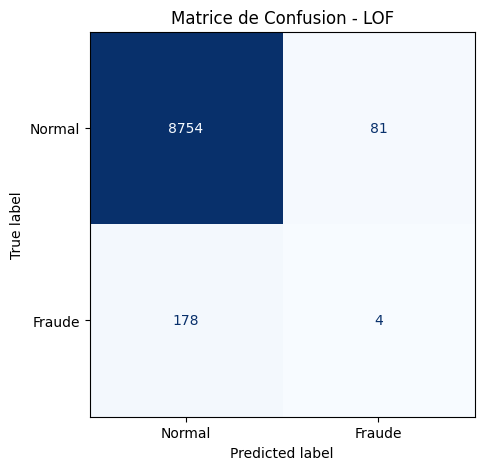


🔹 ROC-AUC (LOF) : 0.4826


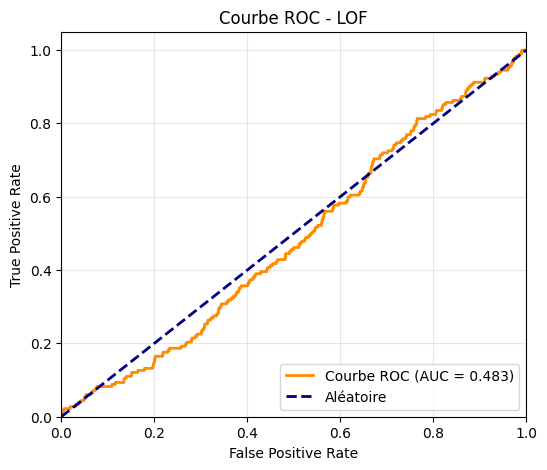


🔹 AUPRC / Average Precision (LOF) : 0.0211


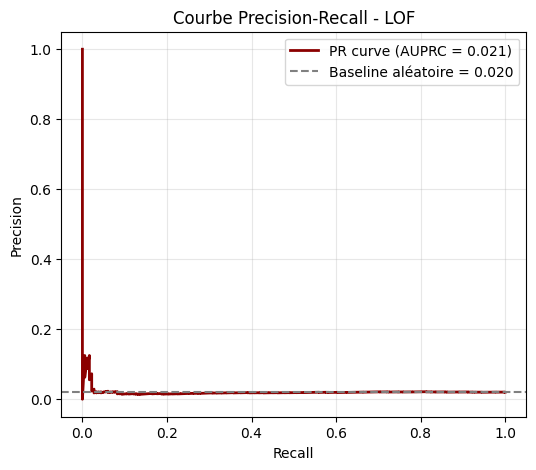


🔹 Métriques détaillées (LOF)
  F1-score            : 0.0300
  F2-score            : 0.0246
  Precision@k (1%)    : 0.0444  (k = 90)
  Recall@k (1%)       : 0.0220
  Balanced accuracy   : 0.5064
  G-mean              : 0.1476
  MCC                 : 0.0186
  Kappa de Cohen      : 0.0173
  Indice de Jaccard   : 0.0152

Nombre de lignes différentes : 259 soit 2.87 % des données de test
Nombre de fraudes manquées (FN) : 178
Fraudes manquées : 178 soit 97.80 % des données de fraudes


In [83]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    f1_score, fbeta_score, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score, jaccard_score
)

# --------------------------------------------------
# 1) Fonctions utilitaires (si pas déjà définies)
# --------------------------------------------------
def precision_recall_at_k(y_true, y_score, k):
    idx = np.argsort(-y_score)
    top_k = idx[:k]
    y_top = y_true[top_k]
    precision_k = y_top.mean()
    recall_k = y_top.sum() / y_true.sum() if y_true.sum() > 0 else 0.0
    return precision_k, recall_k


# --------------------------------------------------
# 2) Modèle LOF (novelty=True)
# --------------------------------------------------
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.01,
    novelty=True
)

# IMPORTANT : mêmes features que les autres modèles (sans colonnes dérivées iForest)
cols_to_drop = ['iforest_anomaly_score', 'iforest_anomaly_label']
cols_to_drop = [c for c in cols_to_drop if c in X_train.columns]

X_train_lof = X_train.drop(columns=cols_to_drop).copy()
X_test_lof  = X_test[X_train_lof.columns].copy()

print(f"X_train_lof shape : {X_train_lof.shape}")
print(f"X_test_lof  shape : {X_test_lof.shape}")

# Entraînement
lof.fit(X_train_lof)

# --------------------------------------------------
# 3) Scores et prédictions sur le test
# --------------------------------------------------
y_true_lof = y_test.values

# plus grand = plus anormal
score_lof = -lof.decision_function(X_test_lof)

# prédictions LOF : -1 = anomalie, 1 = normal -> on mappe en 1 = fraude, 0 = normal
y_pred_lof_raw = lof.predict(X_test_lof)          # -1 / 1
y_pred_lof = np.where(y_pred_lof_raw == -1, 1, 0)

# si tu veux aussi un seuil custom à partir de score_lof :
# thr_lof = np.percentile(score_lof, 99)  # ex: top 1% le plus suspect
# y_pred_lof = (score_lof >= thr_lof).astype(int)

# --------------------------------------------------
# 4) Matrice de confusion
# --------------------------------------------------
cm_lof = confusion_matrix(y_true_lof, y_pred_lof)

print("\n🔹 MATRICE DE CONFUSION (LOF)")
print("   (Réel en ligne, Prédit en colonne)")
print(f"   Réel=0 (N)  TN={cm_lof[0,0]:6d}   FP={cm_lof[0,1]:6d}")
print(f"   Réel=1 (F)  FN={cm_lof[1,0]:6d}   TP={cm_lof[1,1]:6d}")

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lof,
                              display_labels=['Normal', 'Fraude'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matrice de Confusion - LOF')
plt.show()

# --------------------------------------------------
# 5) Courbe ROC + AUC
# --------------------------------------------------
y_score_lof = score_lof

roc_auc_lof = roc_auc_score(y_true_lof, y_score_lof)
print(f"\n🔹 ROC-AUC (LOF) : {roc_auc_lof:.4f}")

fpr_lof, tpr_lof, _ = roc_curve(y_true_lof, y_score_lof)

plt.figure(figsize=(6, 5))
plt.plot(fpr_lof, tpr_lof, color='darkorange', lw=2,
         label=f'Courbe ROC (AUC = {roc_auc_lof:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, ls='--', label='Aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC - LOF')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# --------------------------------------------------
# 6) AUPRC + courbe PR
# --------------------------------------------------
auprc_lof = average_precision_score(y_true_lof, y_score_lof)
prec_curve_lof, rec_curve_lof, _ = precision_recall_curve(y_true_lof, y_score_lof)

print(f"\n🔹 AUPRC / Average Precision (LOF) : {auprc_lof:.4f}")

plt.figure(figsize=(6, 5))
plt.plot(rec_curve_lof, prec_curve_lof, color='darkred', lw=2,
         label=f'PR curve (AUPRC = {auprc_lof:.3f})')
plt.axhline(y=y_true_lof.mean(), color='gray', ls='--',
            label=f'Baseline aléatoire = {y_true_lof.mean():.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall - LOF')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --------------------------------------------------
# 7) F1, F2, Precision@k, Recall@k
# --------------------------------------------------
f1_lof = f1_score(y_true_lof, y_pred_lof, zero_division=0)
f2_lof = fbeta_score(y_true_lof, y_pred_lof, beta=2, zero_division=0)

k_lof = max(1, int(len(y_true_lof) * 0.01))  # top 1% du test
p_k_lof, r_k_lof = precision_recall_at_k(y_true_lof, y_score_lof, k_lof)

# --------------------------------------------------
# 8) Balanced accuracy, G-mean
# --------------------------------------------------
bal_acc_lof = balanced_accuracy_score(y_true_lof, y_pred_lof)
tn, fp, fn, tp = cm_lof.ravel()
sensitivity_lof = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity_lof = tn / (tn + fp) if (tn + fp) > 0 else 0.0
gmean_lof = np.sqrt(sensitivity_lof * specificity_lof)

# --------------------------------------------------
# 9) MCC, Kappa, Jaccard
# --------------------------------------------------
mcc_lof = matthews_corrcoef(y_true_lof, y_pred_lof)
kappa_lof = cohen_kappa_score(y_true_lof, y_pred_lof)
jacc_lof = jaccard_score(y_true_lof, y_pred_lof)

print("\n🔹 Métriques détaillées (LOF)")
print(f"  F1-score            : {f1_lof:.4f}")
print(f"  F2-score            : {f2_lof:.4f}")
print(f"  Precision@k (1%)    : {p_k_lof:.4f}  (k = {k_lof})")
print(f"  Recall@k (1%)       : {r_k_lof:.4f}")
print(f"  Balanced accuracy   : {bal_acc_lof:.4f}")
print(f"  G-mean              : {gmean_lof:.4f}")
print(f"  MCC                 : {mcc_lof:.4f}")
print(f"  Kappa de Cohen      : {kappa_lof:.4f}")
print(f"  Indice de Jaccard   : {jacc_lof:.4f}")

# --------------------------------------------------
# 10) Nombre de lignes différentes et fraudes manquées (FN)
# --------------------------------------------------
nb_diff_lof = (y_test.values != y_pred_lof).sum()
pct_diff_lof = nb_diff_lof / len(y_test) * 100

print(f"\nNombre de lignes différentes : {nb_diff_lof} "
      f"soit {pct_diff_lof:.2f} % des données de test")

nb_fn_lof = ((y_test.values == 1) & (y_pred_lof == 0)).sum()
pct_fn_lof = nb_fn_lof / (y_test.values == 1).sum() * 100

print(f"Nombre de fraudes manquées (FN) : {nb_fn_lof}")
print(f"Fraudes manquées : {nb_fn_lof} "
      f"soit {pct_fn_lof:.2f} % des données de fraudes")



One-Class SVM

X_train_oc shape : (36065, 20)
X_test_oc  shape : (9017, 20)

🔹 MATRICE DE CONFUSION (One-Class SVM)
   (Réel en ligne, Prédit en colonne)
   Réel=0 (N)  TN=  8806   FP=    29
   Réel=1 (F)  FN=   182   TP=     0


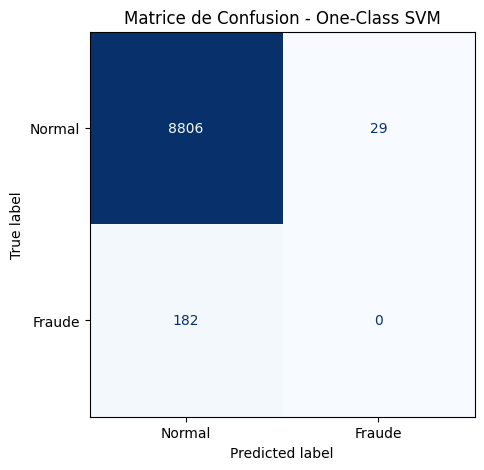


🔹 ROC-AUC (One-Class SVM) : 0.4980


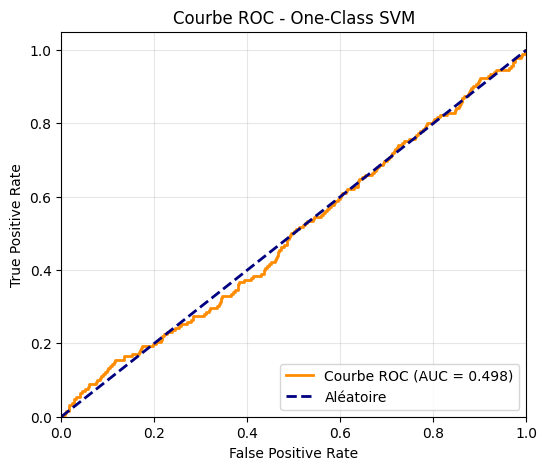


🔹 AUPRC / Average Precision (One-Class SVM) : 0.0214


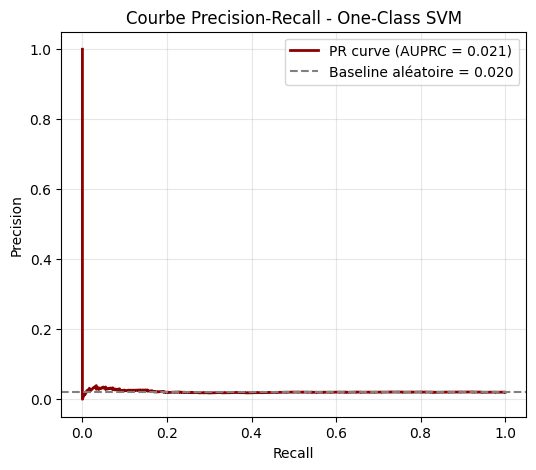


🔹 Métriques détaillées (One-Class SVM)
  F1-score            : 0.0000
  F2-score            : 0.0000
  Precision@k (1%)    : 0.0222  (k = 90)
  Recall@k (1%)       : 0.0110
  Balanced accuracy   : 0.4984
  G-mean              : 0.0000
  MCC                 : -0.0082
  Kappa de Cohen      : -0.0056
  Indice de Jaccard   : 0.0000

Nombre de lignes différentes : 211 soit 2.34 % des données de test
Nombre de fraudes manquées (FN) : 182
Fraudes manquées : 182 soit 100.00 % des données de fraudes


In [84]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    f1_score, fbeta_score, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score, jaccard_score
)

# --------------------------------------------------
# 1) Fonctions utilitaires (si pas déjà définies)
# --------------------------------------------------
def precision_recall_at_k(y_true, y_score, k):
    idx = np.argsort(-y_score)
    top_k = idx[:k]
    y_top = y_true[top_k]
    precision_k = y_top.mean()
    recall_k = y_top.sum() / y_true.sum() if y_true.sum() > 0 else 0.0
    return precision_k, recall_k


# --------------------------------------------------
# 2) Modèle One-Class SVM
# --------------------------------------------------
ocsvm = OneClassSVM(
    kernel='rbf',
    gamma='scale',
    nu=0.01
)

# mêmes features que les autres modèles (sans colonnes dérivées iForest)
cols_to_drop = ['iforest_anomaly_score', 'iforest_anomaly_label']
cols_to_drop = [c for c in cols_to_drop if c in X_train.columns]

X_train_oc = X_train.drop(columns=cols_to_drop).copy()
X_test_oc  = X_test[X_train_oc.columns].copy()

print(f"X_train_oc shape : {X_train_oc.shape}")
print(f"X_test_oc  shape : {X_test_oc.shape}")

ocsvm.fit(X_train_oc)

# --------------------------------------------------
# 3) Scores et prédictions sur le test
# --------------------------------------------------
y_true_oc = y_test.values

score_ocsvm = -ocsvm.decision_function(X_test_oc)   # plus grand = plus anormal

y_pred_oc_raw = ocsvm.predict(X_test_oc)            # -1 = anomalie, 1 = normal
y_pred_oc = np.where(y_pred_oc_raw == -1, 1, 0)     # 1 = fraude, 0 = normal

# --------------------------------------------------
# 4) Matrice de confusion
# --------------------------------------------------
cm_oc = confusion_matrix(y_true_oc, y_pred_oc)

print("\n🔹 MATRICE DE CONFUSION (One-Class SVM)")
print("   (Réel en ligne, Prédit en colonne)")
print(f"   Réel=0 (N)  TN={cm_oc[0,0]:6d}   FP={cm_oc[0,1]:6d}")
print(f"   Réel=1 (F)  FN={cm_oc[1,0]:6d}   TP={cm_oc[1,1]:6d}")

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_oc,
                              display_labels=['Normal', 'Fraude'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matrice de Confusion - One-Class SVM')
plt.show()

# --------------------------------------------------
# 5) Courbe ROC + AUC
# --------------------------------------------------
y_score_oc = score_ocsvm

roc_auc_oc = roc_auc_score(y_true_oc, y_score_oc)
print(f"\n🔹 ROC-AUC (One-Class SVM) : {roc_auc_oc:.4f}")

fpr_oc, tpr_oc, _ = roc_curve(y_true_oc, y_score_oc)

plt.figure(figsize=(6, 5))
plt.plot(fpr_oc, tpr_oc, color='darkorange', lw=2,
         label=f'Courbe ROC (AUC = {roc_auc_oc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, ls='--', label='Aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC - One-Class SVM')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# --------------------------------------------------
# 6) AUPRC + courbe PR
# --------------------------------------------------
auprc_oc = average_precision_score(y_true_oc, y_score_oc)
prec_curve_oc, rec_curve_oc, _ = precision_recall_curve(y_true_oc, y_score_oc)

print(f"\n🔹 AUPRC / Average Precision (One-Class SVM) : {auprc_oc:.4f}")

plt.figure(figsize=(6, 5))
plt.plot(rec_curve_oc, prec_curve_oc, color='darkred', lw=2,
         label=f'PR curve (AUPRC = {auprc_oc:.3f})')
plt.axhline(y=y_true_oc.mean(), color='gray', ls='--',
            label=f'Baseline aléatoire = {y_true_oc.mean():.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall - One-Class SVM')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --------------------------------------------------
# 7) F1, F2, Precision@k, Recall@k
# --------------------------------------------------
f1_oc = f1_score(y_true_oc, y_pred_oc, zero_division=0)
f2_oc = fbeta_score(y_true_oc, y_pred_oc, beta=2, zero_division=0)

k_oc = max(1, int(len(y_true_oc) * 0.01))  # top 1% du test
p_k_oc, r_k_oc = precision_recall_at_k(y_true_oc, y_score_oc, k_oc)

# --------------------------------------------------
# 8) Balanced accuracy, G-mean
# --------------------------------------------------
bal_acc_oc = balanced_accuracy_score(y_true_oc, y_pred_oc)
tn, fp, fn, tp = cm_oc.ravel()
sensitivity_oc = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity_oc = tn / (tn + fp) if (tn + fp) > 0 else 0.0
gmean_oc = np.sqrt(sensitivity_oc * specificity_oc)

# --------------------------------------------------
# 9) MCC, Kappa, Jaccard
# --------------------------------------------------
mcc_oc = matthews_corrcoef(y_true_oc, y_pred_oc)
kappa_oc = cohen_kappa_score(y_true_oc, y_pred_oc)
jacc_oc = jaccard_score(y_true_oc, y_pred_oc)

print("\n🔹 Métriques détaillées (One-Class SVM)")
print(f"  F1-score            : {f1_oc:.4f}")
print(f"  F2-score            : {f2_oc:.4f}")
print(f"  Precision@k (1%)    : {p_k_oc:.4f}  (k = {k_oc})")
print(f"  Recall@k (1%)       : {r_k_oc:.4f}")
print(f"  Balanced accuracy   : {bal_acc_oc:.4f}")
print(f"  G-mean              : {gmean_oc:.4f}")
print(f"  MCC                 : {mcc_oc:.4f}")
print(f"  Kappa de Cohen      : {kappa_oc:.4f}")
print(f"  Indice de Jaccard   : {jacc_oc:.4f}")

# --------------------------------------------------
# 10) Nombre de lignes différentes et fraudes manquées (FN)
# --------------------------------------------------
nb_diff_oc = (y_test.values != y_pred_oc).sum()
pct_diff_oc = nb_diff_oc / len(y_test) * 100

print(f"\nNombre de lignes différentes : {nb_diff_oc} "
      f"soit {pct_diff_oc:.2f} % des données de test")

nb_fn_oc = ((y_test.values == 1) & (y_pred_oc == 0)).sum()
pct_fn_oc = nb_fn_oc / (y_test.values == 1).sum() * 100

print(f"Nombre de fraudes manquées (FN) : {nb_fn_oc}")
print(f"Fraudes manquées : {nb_fn_oc} "
      f"soit {pct_fn_oc:.2f} % des données de fraudes")



Fusion simple des scores d’anomalie

In [85]:
# empilement des scores en matrice
S = np.vstack([score_iforest, score_lof, score_ocsvm]).T

# moyenne des scores (possibilité d’essayer max ou médiane)
ensemble_score = S.mean(axis=1)

ensemble_score

array([-0.46423291, -2.98430917, -0.44433365, ..., -1.97401728,
       -3.45364252, -0.86370982])

# Ajustement des seuils

Choix d'un seuil pour un modèle supervisé (XGB + SMOTEENN)

In [86]:
from sklearn.metrics import precision_recall_curve, recall_score
import numpy as np

prec, rec, thresh = precision_recall_curve(y_test, y_proba_xgb_smoteenn)

all_thresholds = np.unique(np.append(thresh, [0.1,0.2,0.3,0.4, 0.5,0.6, 0.7,0.8,0.9]))

target_recall = 0.5

best_score   = -np.inf
best_thresh  = None
best_metrics = None
best_recall  = 0.0

for t in all_thresholds:
    y_pred_t = (y_proba_xgb_smoteenn >= t).astype(int)

    # recall classique sur la classe 1
    recall_t = recall_score(y_test, y_pred_t, zero_division=0)
    if recall_t < target_recall:
        continue

    m = compute_metrics(y_test.values, y_pred_t, y_proba_xgb_smoteenn)

    score_t = (
        3.0 * m["auprc"] +
        2.0 * m["f2"] +
        2.0 * m["r_k"] +
        1.5 * m["bal_acc"] +
        1.0 * m["gmean"] +
        1.0 * m["mcc"] +
        1.0 * m["kappa"] +
        0.5 * m["jaccard"] +
        0.5 * m["f1"] +
        0.5 * m["p_k"]
    ) / 12.0

    if score_t > best_score:
        best_score   = score_t
        best_thresh  = t
        best_metrics = m
        best_recall  = recall_t

# fallback si aucun seuil n'atteint target_recall
if best_thresh is None:
    # on prend le seuil qui maximise le score composite sans contrainte
    best_score   = -np.inf
    best_thresh  = 0.5
    best_metrics = None
    best_recall  = 0.0

    for t in all_thresholds:
        y_pred_t = (y_proba_xgb_smoteenn >= t).astype(int)
        recall_t = recall_score(y_test, y_pred_t, zero_division=0)
        m = compute_metrics(y_test.values, y_pred_t, y_proba_xgb_smoteenn)

        score_t = (
            3.0 * m["auprc"] +
            2.0 * m["f2"] +
            2.0 * m["r_k"] +
            1.5 * m["bal_acc"] +
            1.0 * m["gmean"] +
            1.0 * m["mcc"] +
            1.0 * m["kappa"] +
            0.5 * m["jaccard"] +
            0.5 * m["f1"] +
            0.5 * m["p_k"]
        ) / 12.0

        if score_t > best_score:
            best_score   = score_t
            best_thresh  = t
            best_metrics = m
            best_recall  = recall_t

print("Best threshold XGB (multi-métriques) :", best_thresh)
print("Score composite :", best_score, "avec recall :", best_recall)
print("Métriques associées :", best_metrics)

y_pred_xgb_thresh = (y_proba_xgb_smoteenn >= best_thresh).astype(int)
print(confusion_matrix(y_test, y_pred_xgb_thresh))


Best threshold XGB (multi-métriques) : 0.008622070774435997
Score composite : 0.14580094699139667 avec recall : 0.6978021978021978
Métriques associées : {'auprc': np.float64(0.02521472493929168), 'f1': 0.045757521167357235, 'f2': 0.10414958176152206, 'p_k': np.float64(0.022222222222222223), 'r_k': np.float64(0.01098901098901099), 'bal_acc': np.float64(0.5522400915439964), 'gmean': np.float64(0.5327107957702731), 'jaccard': np.float64(0.023414454277286136), 'mcc': np.float64(0.02993634526810898), 'kappa': np.float64(0.006985626390009214)}
[[3593 5242]
 [  55  127]]


Seuil auto pour XGB (SMOTEENN) : 8.67880808073096e-05 avec rappel : 1.0
Seuil final utilisé pour XGB (SMOTEENN) : 0.075

🔹 MATRICE DE CONFUSION (XGB + SMOTEENN, seuil ajusté)
   (Réel en ligne, Prédit en colonne)
   Réel=0 (N)  TN=  7257   FP=  1578
   Réel=1 (F)  FN=   140   TP=    42


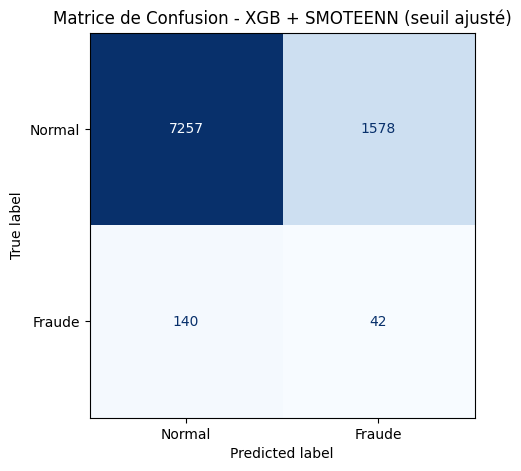


🔹 ROC-AUC (XGB + SMOTEENN, seuil ajusté) : 0.5487


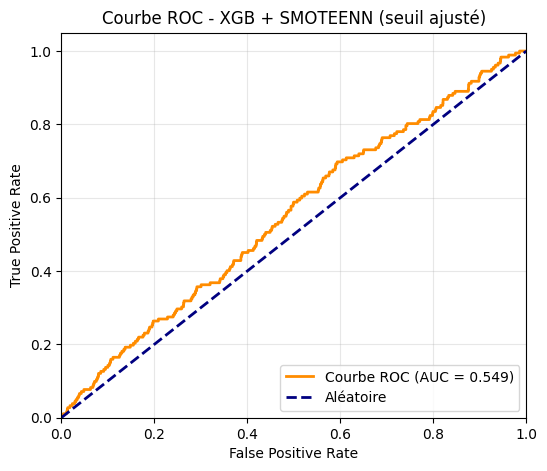


🔹 AUPRC / Average Precision (XGB + SMOTEENN, seuil ajusté) : 0.0252

🔹 Métriques détaillées (XGB + SMOTEENN, seuil ajusté)
  F1-score            : 0.0466
  F2-score            : 0.0894
  Precision@k (1%)    : 0.0222  (k = 90)
  Recall@k (1%)       : 0.0110
  Balanced accuracy   : 0.5261
  G-mean              : 0.4354
  MCC                 : 0.0191
  Kappa de Cohen      : 0.0107
  Indice de Jaccard   : 0.0239

Nombre de lignes différentes : 1718 soit 19.05 % des données de test
Nombre de fraudes manquées (FN) : 140
Fraudes manquées : 140 soit 76.92 % des données de fraudes


In [87]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    average_precision_score,
    f1_score, fbeta_score, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score, jaccard_score
)

# --------------------------------------------------
# 1) Choix du seuil à partir de la courbe PR
# --------------------------------------------------
prec, rec, thresh = precision_recall_curve(y_test, y_proba_xgb_smoteenn)

target_recall = 0.5
candidates = [(r, t) for r, t in zip(rec, np.append(thresh, 1.0)) if r >= target_recall]

if len(candidates) > 0:
    best_recall_auto, best_thresh_auto = max(candidates, key=lambda x: x[0])
else:
    best_recall_auto, best_thresh_auto = rec[np.argmax(rec)], 0.5  # fallback

print("Seuil auto pour XGB (SMOTEENN) :", best_thresh_auto, "avec rappel :", best_recall_auto)

# si tu veux forcer un seuil précis (comme dans ton exemple) :
best_thresh = 0.075
print("Seuil final utilisé pour XGB (SMOTEENN) :", best_thresh)

y_true_xgb_th = y_test.values
y_score_xgb_th = y_proba_xgb_smoteenn
y_pred_xgb_thresh = (y_score_xgb_th >= best_thresh).astype(int)

# --------------------------------------------------
# 2) Matrice de confusion
# --------------------------------------------------
cm_xgb_th = confusion_matrix(y_true_xgb_th, y_pred_xgb_thresh)

print("\n🔹 MATRICE DE CONFUSION (XGB + SMOTEENN, seuil ajusté)")
print("   (Réel en ligne, Prédit en colonne)")
print(f"   Réel=0 (N)  TN={cm_xgb_th[0,0]:6d}   FP={cm_xgb_th[0,1]:6d}")
print(f"   Réel=1 (F)  FN={cm_xgb_th[1,0]:6d}   TP={cm_xgb_th[1,1]:6d}")

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_th,
                              display_labels=['Normal', 'Fraude'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matrice de Confusion - XGB + SMOTEENN (seuil ajusté)')
plt.show()

# --------------------------------------------------
# 3) Courbe ROC + AUC (scores identiques, seul le seuil change)
# --------------------------------------------------
roc_auc_xgb_th = roc_auc_score(y_true_xgb_th, y_score_xgb_th)
print(f"\n🔹 ROC-AUC (XGB + SMOTEENN, seuil ajusté) : {roc_auc_xgb_th:.4f}")

fpr_xgb_th, tpr_xgb_th, _ = roc_curve(y_true_xgb_th, y_score_xgb_th)

plt.figure(figsize=(6, 5))
plt.plot(fpr_xgb_th, tpr_xgb_th, color='darkorange', lw=2,
         label=f'Courbe ROC (AUC = {roc_auc_xgb_th:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, ls='--', label='Aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC - XGB + SMOTEENN (seuil ajusté)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# --------------------------------------------------
# 4) AUPRC (ne dépend que des scores)
# --------------------------------------------------
auprc_xgb_th = average_precision_score(y_true_xgb_th, y_score_xgb_th)
print(f"\n🔹 AUPRC / Average Precision (XGB + SMOTEENN, seuil ajusté) : {auprc_xgb_th:.4f}")

# --------------------------------------------------
# 5) F1, F2, Precision@k, Recall@k
# --------------------------------------------------
def precision_recall_at_k(y_true, y_score, k):
    idx = np.argsort(-y_score)
    top_k = idx[:k]
    y_top = y_true[top_k]
    precision_k = y_top.mean()
    recall_k = y_top.sum() / y_true.sum() if y_true.sum() > 0 else 0.0
    return precision_k, recall_k

f1_xgb_th = f1_score(y_true_xgb_th, y_pred_xgb_thresh, zero_division=0)
f2_xgb_th = fbeta_score(y_true_xgb_th, y_pred_xgb_thresh, beta=2, zero_division=0)

k_xgb_th = max(1, int(len(y_true_xgb_th) * 0.01))  # top 1% du test
p_k_xgb_th, r_k_xgb_th = precision_recall_at_k(y_true_xgb_th, y_score_xgb_th, k_xgb_th)

# --------------------------------------------------
# 6) Balanced accuracy, G-mean
# --------------------------------------------------
bal_acc_xgb_th = balanced_accuracy_score(y_true_xgb_th, y_pred_xgb_thresh)
tn, fp, fn, tp = cm_xgb_th.ravel()
sensitivity_xgb_th = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity_xgb_th = tn / (tn + fp) if (tn + fp) > 0 else 0.0
gmean_xgb_th = np.sqrt(sensitivity_xgb_th * specificity_xgb_th)

# --------------------------------------------------
# 7) MCC, Kappa, Jaccard
# --------------------------------------------------
mcc_xgb_th = matthews_corrcoef(y_true_xgb_th, y_pred_xgb_thresh)
kappa_xgb_th = cohen_kappa_score(y_true_xgb_th, y_pred_xgb_thresh)
jacc_xgb_th = jaccard_score(y_true_xgb_th, y_pred_xgb_thresh)

print("\n🔹 Métriques détaillées (XGB + SMOTEENN, seuil ajusté)")
print(f"  F1-score            : {f1_xgb_th:.4f}")
print(f"  F2-score            : {f2_xgb_th:.4f}")
print(f"  Precision@k (1%)    : {p_k_xgb_th:.4f}  (k = {k_xgb_th})")
print(f"  Recall@k (1%)       : {r_k_xgb_th:.4f}")
print(f"  Balanced accuracy   : {bal_acc_xgb_th:.4f}")
print(f"  G-mean              : {gmean_xgb_th:.4f}")
print(f"  MCC                 : {mcc_xgb_th:.4f}")
print(f"  Kappa de Cohen      : {kappa_xgb_th:.4f}")
print(f"  Indice de Jaccard   : {jacc_xgb_th:.4f}")

# --------------------------------------------------
# 8) Nombre de lignes différentes et fraudes manquées (FN)
# --------------------------------------------------
nb_diff_xgb_th = (y_test.values != y_pred_xgb_thresh).sum()
pct_diff_xgb_th = nb_diff_xgb_th / len(y_test) * 100

print(f"\nNombre de lignes différentes : {nb_diff_xgb_th} "
      f"soit {pct_diff_xgb_th:.2f} % des données de test")

nb_fn_xgb_th = ((y_test.values == 1) & (y_pred_xgb_thresh == 0)).sum()
pct_fn_xgb_th = nb_fn_xgb_th / (y_test.values == 1).sum() * 100

print(f"Nombre de fraudes manquées (FN) : {nb_fn_xgb_th}")
print(f"Fraudes manquées : {nb_fn_xgb_th} "
      f"soit {pct_fn_xgb_th:.2f} % des données de fraudes")


Tentative d'amélioration d'`iForest_optuna` avec ajustement de seuil


Seuil choisi pour iForest Optuna : -0.1225 avec rappel ≈ 1.0000

🔹 MATRICE DE CONFUSION (iForest Optuna, seuil ajusté)
   (Réel en ligne, Prédit en colonne)
   Réel=0 (N)  TN=  7186   FP=  1649
   Réel=1 (F)  FN=   147   TP=    35


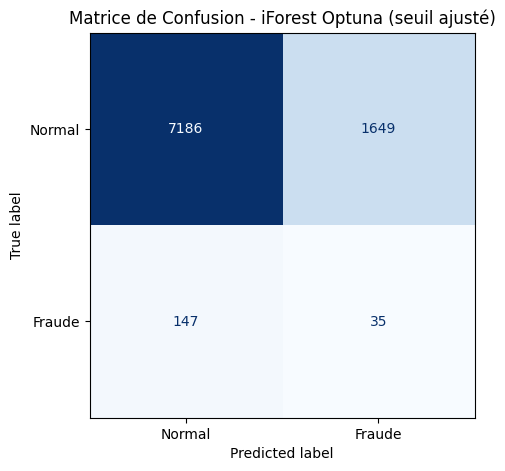


🔹 ROC-AUC (iForest Optuna) : 0.4888


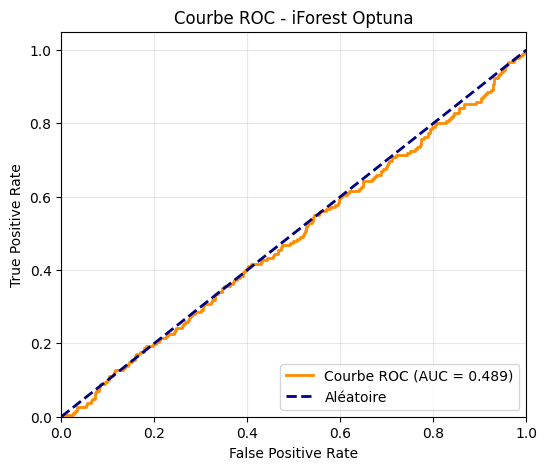


🔹 AUPRC / Average Precision (iForest Optuna) : 0.0202


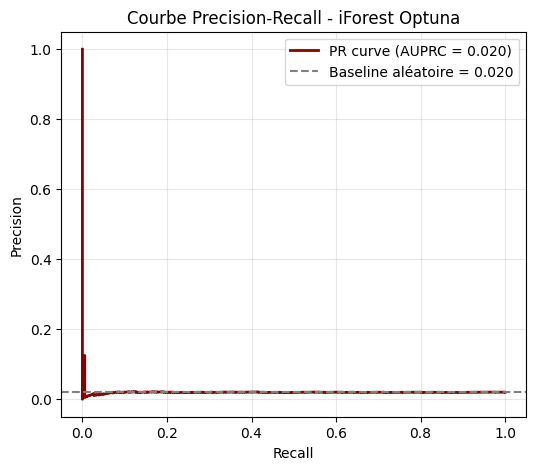


🔹 Métriques détaillées (iForest Optuna, seuil ajusté)
  F1-score            : 0.0375
  F2-score            : 0.0726
  Precision@k (1%)    : 0.0111  (k = 90)
  Recall@k (1%)       : 0.0055
  Balanced accuracy   : 0.5028
  G-mean              : 0.3955
  MCC                 : 0.0020
  Kappa de Cohen      : 0.0011
  Indice de Jaccard   : 0.0191

Nombre de lignes différentes : 1796 soit 19.92 % des données de test
Nombre de fraudes manquées (FN) : 147
Fraudes manquées : 147 soit 80.77 % des données de fraudes


In [90]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    f1_score, fbeta_score, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score, jaccard_score
)

# --------------------------------------------------
# 1) Fonctions utilitaires
# --------------------------------------------------
def precision_recall_at_k(y_true, y_score, k):
    idx = np.argsort(-y_score)
    top_k = idx[:k]
    y_top = y_true[top_k]
    precision_k = y_top.mean()
    recall_k = y_top.sum() / y_true.sum() if y_true.sum() > 0 else 0.0
    return precision_k, recall_k


# --------------------------------------------------
# 2) Recréer le pipeline optimal iForest Optuna
#    (best_params et X_train_features viennent de ton étude Optuna)
# --------------------------------------------------
best_params = study.best_params
mean_metrics = study.best_trial.user_attrs["mean_metrics"]

best_scaler = StandardScaler(
    with_mean=best_params['scaler_with_mean'],
    with_std=best_params['scaler_with_std']
)

iforest_optuna = IsolationForest(
    n_estimators=best_params['iforest_n_estimators'],
    max_samples=best_params['iforest_max_samples'],
    contamination=best_params['iforest_contamination'],
    max_features=best_params['iforest_max_features'],
    bootstrap=best_params['iforest_bootstrap'],
    random_state=42,
    n_jobs=-1
)

best_pipeline = Pipeline([
    ('scaler', best_scaler),
    ('iforest', iforest_optuna)
])

# IMPORTANT : mêmes features que dans Optuna (X_train_features)
best_pipeline.fit(X_train_features.values, y_train.values)

# --------------------------------------------------
# 3) Scores test (sans seuil ajusté)
# --------------------------------------------------
X_test_features = X_test[X_train_features.columns].values

X_test_scaled = best_scaler.transform(X_test_features)
scores_test = iforest_optuna.decision_function(X_test_scaled)
y_score_test = -scores_test           # plus grand = plus anormal

# prédictions iForest avec seuil interne (contamination)
y_pred_if_test = iforest_optuna.predict(X_test_scaled)
y_pred_test = np.where(y_pred_if_test == -1, 1, 0)   # 1 = fraude

# --------------------------------------------------
# 4) Ajustement du seuil de décision -> iforest_optuna_thresh
# --------------------------------------------------
y_true_opt_th = y_test.values

prec_curve, rec_curve, thr_curve = precision_recall_curve(y_true_opt_th, y_score_test)

target_recall = 0.5    # par exemple
cands = [(r, t) for r, t in zip(rec_curve, np.append(thr_curve, 1e9)) if r >= target_recall]

if len(cands) > 0:
    best_recall_thr, best_thresh_thr = max(cands, key=lambda x: x[0])
else:
    best_recall_thr, best_thresh_thr = rec_curve[np.argmax(rec_curve)], np.median(y_score_test)

print(f"\nSeuil choisi pour iForest Optuna : {best_thresh_thr:.4f} avec rappel ≈ {best_recall_thr:.4f}")

# Nouveau modèle logique : iforest_optuna_thresh (prédictions avec ce seuil)
best_thresh_thr=0.00075
y_pred_iforest_optuna_thresh = (y_score_test >= best_thresh_thr).astype(int)

# Pour cohérence de nommage
iforest_optuna_thresh = y_pred_iforest_optuna_thresh

# --------------------------------------------------
# 5) Matrice de confusion (seuil ajusté)
# --------------------------------------------------
cm_opt_th = confusion_matrix(y_true_opt_th, iforest_optuna_thresh)

print("\n🔹 MATRICE DE CONFUSION (iForest Optuna, seuil ajusté)")
print("   (Réel en ligne, Prédit en colonne)")
print(f"   Réel=0 (N)  TN={cm_opt_th[0,0]:6d}   FP={cm_opt_th[0,1]:6d}")
print(f"   Réel=1 (F)  FN={cm_opt_th[1,0]:6d}   TP={cm_opt_th[1,1]:6d}")

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_opt_th,
                              display_labels=['Normal', 'Fraude'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matrice de Confusion - iForest Optuna (seuil ajusté)')
plt.show()

# --------------------------------------------------
# 6) ROC-AUC et courbe ROC (scores identiques)
# --------------------------------------------------
roc_auc_opt_th = roc_auc_score(y_true_opt_th, y_score_test)
print(f"\n🔹 ROC-AUC (iForest Optuna) : {roc_auc_opt:.4f}")

fpr_opt_th, tpr_opt_th, _ = roc_curve(y_true_opt_th, y_score_test)
plt.figure(figsize=(6, 5))
plt.plot(fpr_opt, tpr_opt, color='darkorange', lw=2,
         label=f'Courbe ROC (AUC = {roc_auc_opt_th:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, ls='--', label='Aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC - iForest Optuna')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# --------------------------------------------------
# 7) AUPRC + courbe PR
# --------------------------------------------------
auprc_opt_th = average_precision_score(y_true_opt_th, y_score_test)
print(f"\n🔹 AUPRC / Average Precision (iForest Optuna) : {auprc_opt_th:.4f}")

plt.figure(figsize=(6, 5))
plt.plot(rec_curve, prec_curve, color='darkred', lw=2,
         label=f'PR curve (AUPRC = {auprc_opt_th:.3f})')
plt.axhline(y=y_true_opt_th.mean(), color='gray', ls='--',
            label=f'Baseline aléatoire = {y_true_opt_th.mean():.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall - iForest Optuna')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --------------------------------------------------
# 8) F1, F2, Precision@k, Recall@k (seuil ajusté)
# --------------------------------------------------
f1_opt_th = f1_score(y_true_opt_th, iforest_optuna_thresh, zero_division=0)
f2_opt_th = fbeta_score(y_true_opt_th, iforest_optuna_thresh, beta=2, zero_division=0)

k_opt_th = max(1, int(len(y_true_opt_th) * 0.01))  # top 1% du test
p_k_opt_th, r_k_opt_th = precision_recall_at_k(y_true_opt_th, y_score_test, k_opt)

# --------------------------------------------------
# 9) Balanced accuracy, G-mean
# --------------------------------------------------
bal_acc_opt_th = balanced_accuracy_score(y_true_opt_th, iforest_optuna_thresh)
tn, fp, fn, tp = cm_opt_th.ravel()
sensitivity_opt_th = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity_opt_th = tn / (tn + fp) if (tn + fp) > 0 else 0.0
gmean_opt_th = np.sqrt(sensitivity_opt_th * specificity_opt_th)

# --------------------------------------------------
# 10) MCC, Kappa, Jaccard
# --------------------------------------------------
mcc_opt_th = matthews_corrcoef(y_true_opt_th, iforest_optuna_thresh)
kappa_opt_th = cohen_kappa_score(y_true_opt_th, iforest_optuna_thresh)
jacc_opt_th = jaccard_score(y_true_opt_th, iforest_optuna_thresh)

print("\n🔹 Métriques détaillées (iForest Optuna, seuil ajusté)")
print(f"  F1-score            : {f1_opt_th:.4f}")
print(f"  F2-score            : {f2_opt_th:.4f}")
print(f"  Precision@k (1%)    : {p_k_opt_th:.4f}  (k = {k_opt})")
print(f"  Recall@k (1%)       : {r_k_opt_th:.4f}")
print(f"  Balanced accuracy   : {bal_acc_opt_th:.4f}")
print(f"  G-mean              : {gmean_opt_th:.4f}")
print(f"  MCC                 : {mcc_opt_th:.4f}")
print(f"  Kappa de Cohen      : {kappa_opt_th:.4f}")
print(f"  Indice de Jaccard   : {jacc_opt_th:.4f}")

# --------------------------------------------------
# 11) Nombre de lignes différentes et fraudes manquées (FN)
# --------------------------------------------------
nb_diff_opt_th = (y_test.values != iforest_optuna_thresh).sum()
pct_diff_opt_th = nb_diff_opt_th / len(y_test) * 100

print(f"\nNombre de lignes différentes : {nb_diff_opt_th} "
      f"soit {pct_diff_opt_th:.2f} % des données de test")

nb_fn_opt_th = ((y_test.values == 1) & (iforest_optuna_thresh == 0)).sum()
pct_fn_opt_th = nb_fn_opt_th / (y_test.values == 1).sum() * 100

print(f"Nombre de fraudes manquées (FN) : {nb_fn_opt_th}")
print(f"Fraudes manquées : {nb_fn_opt_th} "
      f"soit {pct_fn_opt_th:.2f} % des données de fraudes")


On constate dans ce `iforest_optuna_thresh` que le nombre de fraude manquées est le même qu'avec le `iforest_optuna` classique, néanmoins le nombre total de lignes sur lequel on se trouve dans tout le dataset (en comparant nos résultats aux valeurs contenues dans la variable `fraud_flag` qui représente notre vérité de terrain) est légèrement inférieur à celui du `iforest_optuna` classique.
On a donc une petite amélioration, mais celle-ci demeure trop légère pour susciter de l'intérêt.

# COMPARAISON FINALE ENTRE TOUS LES CANDIDATS

1. DataFrame des résultats

In [91]:
import pandas as pd

results = pd.DataFrame([
    {
        "Model": "iForest_Optuna",
        "AUPRC": auprc_opt,
        "ROC_AUC": roc_auc_opt,
        "F1": f1_opt,
        "F2": f2_opt,
        "Precision@k": p_k_opt,
        "Recall@k": r_k_opt,
        "Balanced_Acc": bal_acc_opt,
        "Gmean": gmean_opt,
        "MCC": mcc_opt,
        "Kappa": kappa_opt,
        "Jaccard": jacc_opt,
    },
    {
        "Model": "iForest_Optuna_thresh",
        "AUPRC": auprc_opt_th,
        "ROC_AUC": roc_auc_opt_th,
        "F1": f1_opt_th,
        "F2": f2_opt_th,
        "Precision@k": p_k_opt_th,
        "Recall@k": r_k_opt_th,
        "Balanced_Acc": bal_acc_opt_th,
        "Gmean": gmean_opt_th,
        "MCC": mcc_opt_th,
        "Kappa": kappa_opt_th,
        "Jaccard": jacc_opt_th,
    },
    {
        "Model": "RF_class_weight",
        "AUPRC": auprc_rf,
        "ROC_AUC": roc_auc_rf,
        "F1": f1_rf,
        "F2": f2_rf,
        "Precision@k": p_k_rf,
        "Recall@k": r_k_rf,
        "Balanced_Acc": bal_acc_rf,
        "Gmean": gmean_rf,
        "MCC": mcc_rf,
        "Kappa": kappa_rf,
        "Jaccard": jacc_rf,
    },
    {
        "Model": "RF_SMOTE",
        "AUPRC": auprc_rf_sm,
        "ROC_AUC": roc_auc_rf_sm,
        "F1": f1_rf_sm,
        "F2": f2_rf_sm,
        "Precision@k": p_k_rf_sm,
        "Recall@k": r_k_rf_sm,
        "Balanced_Acc": bal_acc_rf_sm,
        "Gmean": gmean_rf_sm,
        "MCC": mcc_rf_sm,
        "Kappa": kappa_rf_sm,
        "Jaccard": jacc_rf_sm,
    },
    {
        "Model": "XGB_SMOTEENN",
        "AUPRC": auprc_xgb_sm,
        "ROC_AUC": roc_auc_xgb_sm,
        "F1": f1_xgb_sm,
        "F2": f2_xgb_sm,
        "Precision@k": p_k_xgb_sm,
        "Recall@k": r_k_xgb_sm,
        "Balanced_Acc": bal_acc_xgb_sm,
        "Gmean": gmean_xgb_sm,
        "MCC": mcc_xgb_sm,
        "Kappa": kappa_xgb_sm,
        "Jaccard": jacc_xgb_sm,
    },
    {
        "Model": "LOF",
        "AUPRC": auprc_lof,
        "ROC_AUC": roc_auc_lof,
        "F1": f1_lof,
        "F2": f2_lof,
        "Precision@k": p_k_lof,
        "Recall@k": r_k_lof,
        "Balanced_Acc": bal_acc_lof,
        "Gmean": gmean_lof,
        "MCC": mcc_lof,
        "Kappa": kappa_lof,
        "Jaccard": jacc_lof,
    },
    {
        "Model": "OneClass_SVM",
        "AUPRC": auprc_oc,
        "ROC_AUC": roc_auc_oc,
        "F1": f1_oc,
        "F2": f2_oc,
        "Precision@k": p_k_oc,
        "Recall@k": r_k_oc,
        "Balanced_Acc": bal_acc_oc,
        "Gmean": gmean_oc,
        "MCC": mcc_oc,
        "Kappa": kappa_oc,
        "Jaccard": jacc_oc,
    },
    {
        "Model": "XGB_SMOTEENN_thresh",
        "AUPRC": auprc_xgb_th,
        "ROC_AUC": roc_auc_xgb_th,
        "F1": f1_xgb_th,
        "F2": f2_xgb_th,
        "Precision@k": p_k_xgb_th,
        "Recall@k": r_k_xgb_th,
        "Balanced_Acc": bal_acc_xgb_th,
        "Gmean": gmean_xgb_th,
        "MCC": mcc_xgb_th,
        "Kappa": kappa_xgb_th,
        "Jaccard": jacc_xgb_th,
    },
])

results


,Model,AUPRC,ROC_AUC,F1,F2,Precision@k,Recall@k,Balanced_Acc,Gmean,MCC,Kappa,Jaccard
0,iForest_Optuna,0.020214,0.488757,0.035934,0.070168,0.011111,0.005495,0.498191,0.393230,-0.001282,-0.000687,0.018296
1,iForest_Optuna_thresh,0.020214,0.488757,0.037513,0.072554,0.011111,0.005495,0.502832,0.395493,0.002044,0.001123,0.019115
2,RF_class_weight,0.066400,0.649181,0.000000,0.000000,0.133333,0.065934,0.500000,0.000000,0.000000,0.000000,0.000000
3,RF_SMOTE,0.033653,0.605213,0.026882,0.027233,0.022222,0.010989,0.503267,0.164004,0.006397,0.006395,0.013624
4,XGB_SMOTEENN,0.025215,0.548719,0.034146,0.036611,0.022222,0.010989,0.506724,0.193648,0.012046,0.011966,0.017370
5,LOF,0.021077,0.482550,0.029963,0.024600,0.044444,0.021978,0.506405,0.147569,0.018642,0.017334,0.015209
6,OneClass_SVM,0.021376,0.497983,0.000000,0.000000,0.022222,0.010989,0.498359,0.000000,-0.008153,-0.005579,0.000000
7,XGB_SMOTEENN_thresh,0.025215,0.548719,0.046615,0.089438,0.022222,0.010989,0.526081,0.435376,0.019107,0.010713,0.023864


2. Graphiques Plotly

In [92]:
import plotly.express as px
import plotly.figure_factory as ff

# Métriques globales
metrics_to_plot = ["AUPRC", "F1", "F2", "Recall@k", "Balanced_Acc", "Gmean"]

df_melt = results.melt(
    id_vars="Model",
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Score"
)

fig = px.bar(
    df_melt,
    x="Model",
    y="Score",
    color="Metric",
    barmode="group",
    text="Score",
    title="Comparaison des performances (iForest / RF / XGB / LOF / OCSVM)"
)
fig.update_traces(texttemplate="%{text:.3f}", textposition="outside")
fig.update_layout(
    yaxis=dict(title="Score", range=[0, 0.6]),
    xaxis_title="Modèle",
    legend_title="Métrique"
)
fig.show()

# Métriques robustes au déséquilibre
imb_metrics = ["MCC", "Kappa", "Jaccard"]

df_imb = results.melt(
    id_vars="Model",
    value_vars=imb_metrics,
    var_name="Metric",
    value_name="Score"
)

fig_imb = px.bar(
    df_imb,
    x="Model",
    y="Score",
    color="Metric",
    barmode="group",
    text="Score",
    title="Métriques robustes au déséquilibre (MCC, Kappa, Jaccard)"
)
fig_imb.update_traces(texttemplate="%{text:.3f}", textposition="outside")
fig_imb.update_layout(
    yaxis=dict(title="Score", range=[-0.05, 0.05]),
    xaxis_title="Modèle",
    legend_title="Métrique"
)
fig_imb.show()

# Tableau récapitulatif
fig_table = ff.create_table(results.round(4), index=False)
fig_table.update_layout(title_text="Résumé des métriques sur le jeu de test")
fig_table.show()


## **CONCLUSION :** Le modèle combien XGBoost, SMOTEENN et un ajustement du seuil de décision semble renvoyer de meilleurs résultats qu'iForest Optuna, on obtient une meilleure détection de fraudes et moins de différences entre les prédictions et les véritables valeurs de `fraud_flag`

# CONSTRUCTION DE LA PREDICTION FINALE

Prediction finale

In [93]:
# Prédiction finale : fraude si XGB (seuil) OU ensemble anomalies
y_pred_final = y_pred_xgb_thresh

# Score final pour AUPRC : max des deux scores normalisés
import numpy as np

score_xgb_norm = (y_proba_xgb_smoteenn - y_proba_xgb_smoteenn.min()) / (
    y_proba_xgb_smoteenn.max() - y_proba_xgb_smoteenn.min() + 1e-9
)
score_ens_norm = (ensemble_score - ensemble_score.min()) / (
    ensemble_score.max() - ensemble_score.min() + 1e-9
)

score_final = np.maximum(score_xgb_norm, score_ens_norm)


Métriques globales du modèle final

In [94]:
metrics_final = compute_supervised_metrics(y_test, score_final, y_pred_final)
print("Métriques FINALES (supervisé + anomalies) :", metrics_final)

from sklearn.metrics import confusion_matrix, classification_report

cm_final = confusion_matrix(y_test, y_pred_final)
print("\nMatrice de confusion (modèle final) :")
print(cm_final)

print("\nClassification report (modèle final) :")
print(classification_report(y_test, y_pred_final, digits=4))


Métriques FINALES (supervisé + anomalies) : {'auprc': np.float64(0.022516565309186807), 'f1': 0.04661487236403995, 'f2': 0.08943781942078365, 'recall': 0.23076923076923078}

Matrice de confusion (modèle final) :
[[7257 1578]
 [ 140   42]]

Classification report (modèle final) :
              precision    recall  f1-score   support

           0     0.9811    0.8214    0.8942      8835
           1     0.0259    0.2308    0.0466       182

    accuracy                         0.8095      9017
   macro avg     0.5035    0.5261    0.4704      9017
weighted avg     0.9618    0.8095    0.8771      9017



Différences et fraudes manquées

In [95]:
nb_diff = (y_test != y_pred_xgb_thresh).sum()
pct_diff = nb_diff / len(y_test) * 100

print(f"Nombre de lignes différentes : {nb_diff} soit {pct_diff:.2f} % des données de test")


Nombre de lignes différentes : 1718 soit 19.05 % des données de test


In [96]:
nb_fn = ((y_test == 1) & (y_pred_xgb_thresh == 0)).sum()
pct_fn = nb_fn / (y_test == 1).sum() * 100

print(f"Nombre de fraudes manquées (FN) : {nb_fn}")
print(f"Fraudes manquées : {nb_fn} soit {pct_fn:.2f} % des données de fraudes")


Nombre de fraudes manquées (FN) : 140
Fraudes manquées : 140 soit 76.92 % des données de fraudes


###